# **Capstone Project Module 2**<br>
<br>
Data Analysis End-to-End : E-commerce Tokopedia<br>
Oleh : Annisa Andez Aunillah

# **Background**

Pertumbuhan industri *e-commerce* di Indonesia dalam satu dekade terakhir menunjukkan tren yang sangat masif, di mana Tokopedia menjadi salah satu pemain utama yang mendominasi pasar. Dengan jutaan pengguna aktif bulanan dan jutaan merchant yang terdaftar, platform ini menjadi ekosistem ekonomi digital yang sangat kompleks. Setiap harinya, ratusan ribu transaksi terjadi, mencakup berbagai kategori produk mulai dari kebutuhan sehari-hari, elektronik, hingga produk finansial.
Tingginya volume transaksi ini tentu menjadi indikator positif bagi pertumbuhan GMV (*Gross Merchandise Value*). Namun, di balik angka besar tersebut, manajemen mulai menyadari adanya tantangan dalam menjaga efisiensi operasional dan profitabilitas. Strategi "bakar uang" melalui promo Waktu Indonesia Belanja (WIB), cashback, dan subsidi ongkir memang efektif untuk akuisisi pengguna baru, tetapi retensi pengguna jangka panjang masih menjadi tanda tanya besar.
Laporan kuartal terakhir dari tim operasional dan customer success menunjukkan tren yang mengkhawatirkan. Terjadi peningkatan *Customer Acquisition Cost* (CAC) yang tidak berbanding lurus dengan *Customer Lifetime Value* (CLV). Artinya, banyak user yang hanya bertransaksi saat ada promo besar-besaran, lalu churn (tidak aktif lagi) di bulan-bulan berikutnya. Selain itu, keluhan terkait keterlambatan pengiriman juga mulai membanjiri customer service, yang berpotensi merusak trust pengguna terhadap platform.
Di sisi lain, tim Data Engineer melaporkan bahwa data pipeline dari sistem legacy ke data warehouse saat ini sering mengalami anomali. Banyak log transaksi yang masuk dengan format yang tidak standar, data yang kosong, hingga timestamp yang tidak masuk akal akibat glitch pada sistem saat traffic sedang puncak (misalnya saat flash sale). Hal ini membuat tim bisnis kesulitan mendapatkan insights yang akurat melalui dashboard mereka.
Oleh karena itu, analisis mendalam terhadap histori transaksi, profil pengguna, dan performa pengiriman ini mutlak harus dilakukan. Tanpa adanya pembersihan data (*data cleansing*) yang menyeluruh dan analisis pola transaksi, manajemen tidak akan bisa mengidentifikasi kebocoran budget promo, memperbaiki bottleneck di sisi logistik, serta merumuskan strategi retensi pelanggan yang berbasis data. Analisis ini adalah langkah krusial untuk mengubah strategi bisnis Tokopedia dari yang sekadar *growth-driven* menjadi *profitability-driven*.


# **Problem Statement**

**Masalah Utama**: Penurunan efisiensi profitabilitas dan tingkat retensi pengguna akibat distribusi promo yang tidak tepat sasaran serta adanya *bottleneck pada* proses pemenuhan pesanan (logistik).

**Masalah Turunan**:
1.	Segmen user mana yang memiliki kecenderungan menjadi *promo-hunter* (hanya belanja saat ada promo lalu churn)?
2.	Seberapa besar dampak keterlambatan pengiriman (SLA miss) terhadap kemungkinan user melakukan *repeat order*?
3.	Metode pembayaran apa yang paling sering mengalami anomali transaksi atau *drop-off*?
4.	Bagaimana korelasi antara lokasi user dan durasi pengiriman terhadap total nilai transaksi (GMV)?
5.	Apakah ada anomali data sistem (seperti tanggal transaksi mendahului tanggal registrasi) yang mengindikasikan kebocoran atau bug pada platform?
6.	Berapa persentase budget promo yang sebenarnya terbuang untuk transaksi-transaksi yang secara bisnis tidak valid (*outliers & fraud*)?


# **Goals**

Jika analisis ini berhasil dan masalah di atas dapat diselesaikan, maka goals yang akan dicapai adalah:
1. **Optimalisasi Budget Promo**: Mampu mengalokasikan promo hanya kepada segmen user yang memiliki potensi CLV (*Customer Lifetime Value*) tinggi, bukan kepada promo-hunter.
2. **Peningkatan SLA Logistik**: Menemukan rekanan kurir atau rute pengiriman yang bermasalah untuk segera dievaluasi, sehingga komplain keterlambatan turun minimal 20%.
3. **Data Reliability**: Menghasilkan dataset yang sudah bersih (clean) yang bisa dijadikan single source of truth untuk pembuatan dashboard BI atau machine learning model di masa depan.
4. **Peningkatan Retensi**: Meningkatkan angka repeat order dengan memperbaiki pengalaman pengguna berdasarkan pain points yang ditemukan.


# **Stakeholder**<br>
1. Optimalisasi Budget Promo = Marketing
2. Peningkatan SLA Logistik = Supply Chain Operations
3. Data realibility = Data Engineering, IT
4. Peningkatan retensi : Customer Service

# **Dataset Dictionary**

Dataset terdiri dari 3 tabel. Total baris di tabel transactions dan deliveries adalah 300.000 baris.

1. **Tabel users.csv (Dimensi User)**<br>
●	user_id: ID unik pengguna.<br>
●	join_date: Tanggal pengguna mendaftar di Tokopedia.<br>
●	gender: Jenis kelamin pengguna.<br>
●	location: Kota domisili pengguna.<br>
●	age: Umur pengguna.<br>

2. **Tabel transactions.csv (Fakta Transaksi - 300k baris)**<br>
●	order_id: ID unik transaksi.<br>
●	user_id: ID pengguna yang bertransaksi.<br>
●	order_date: Tanggal transaksi dilakukan.<br>
●	payment_method: Metode pembayaran.<br>
●	promo_amount: Nominal diskon yang digunakan.<br>
●	total_amount: Total nilai belanja.<br>

3. **Tabel deliveries.csv (Fakta Pengiriman - 300k baris)**<br>
●	order_id: ID transaksi yang dikirim.<br>
●	courier_name: Nama ekspedisi pengiriman.<br>
●	dispatch_date: Tanggal barang diserahkan seller ke kurir.<br>
●	delivery_date: Tanggal barang sampai ke pembeli.<br>

# **ETL Proccess**

## **Extract Data**

In [1]:
# Import Library yang dibutuhkan

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Import Data Tokopedia

delivery=pd.read_csv('tokopedia_deliveries.csv')
transactions=pd.read_csv('tokopedia_transactions.csv')
users=pd.read_csv('tokopedia_users.csv')

display(delivery)
display(transactions)
display(users)

,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26
3,ORD000004,GoTo Logistics,2024-06-18,2024-06-23
4,ORD000005,SiCepat,2024-03-13,2024-03-14
...,...,...,...,...
299995,ORD299996,GoTo Logistics,2024-06-14,2024-06-20
299996,ORD299997,JNE,2023-02-10,2023-02-12
299997,ORD299998,GoTo Logistics,2023-03-14,2023-03-19
299998,ORD299999,GoTo Logistics,2023-04-11,2023-04-15


,order_id,user_id,order_date,payment_method,promo_amount,total_amount
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947
1,ORD000002,USR26336,2022-08-10,ovo,10000,1054104
2,ORD000003,USR25466,2024-05-21,COD,0,1067647
3,ORD000004,USR42303,2024-06-18,ovo,10000,175629
4,ORD000005,USR29370,2024-03-11,ovo,0,1438378
...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GO-PAY,10000,1664986
299996,ORD299997,USR34293,2023-02-09,bca va,0,1879130
299997,ORD299998,USR18612,2023-03-14,gopay,10000,973388
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572


,user_id,join_date,gender,location,age
0,USR00001,2022-04-13,Female,Yogyakarta,21
1,USR00002,2023-03-12,Female,Bandung,33
2,USR00003,2022-09-28,Female,Bandung,20
3,USR00004,2022-04-17,Female,Bandung,25
4,USR00005,2022-03-13,Female,Bandung,56
...,...,...,...,...,...
49995,USR49996,2022-09-03,Male,Medan,62
49996,USR49997,2022-07-03,NaN,Surabaya,60
49997,USR49998,2023-02-17,Male,Yogyakarta,49
49998,USR49999,2022-09-30,Male,Makassar,54


## **Data Cleaning**

### **Data Cleaning Tabel Users**

In [3]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    50000 non-null  str  
 1   join_date  50000 non-null  str  
 2   gender     45106 non-null  str  
 3   location   50000 non-null  str  
 4   age        50000 non-null  int64
dtypes: int64(1), str(4)
memory usage: 3.3 MB


In [4]:
# Cek apakah ada duplikat di kolom user_id

users['user_id'].unique()

<ArrowStringArray>
['USR00001', 'USR00002', 'USR00003', 'USR00004', 'USR00005', 'USR00006',
 'USR00007', 'USR00008', 'USR00009', 'USR00010',
 ...
 'USR49991', 'USR49992', 'USR49993', 'USR49994', 'USR49995', 'USR49996',
 'USR49997', 'USR49998', 'USR49999', 'USR50000']
Length: 50000, dtype: str

Jumlah data unique di kolom user_id ada 50.000 maka `kolom user_id` pada `tabel users` sudah unique.

In [5]:
# Ubah format join_date menjadi date_time
users['join_date']=pd.to_datetime(users['join_date'])
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    50000 non-null  str           
 1   join_date  50000 non-null  datetime64[us]
 2   gender     45106 non-null  str           
 3   location   50000 non-null  str           
 4   age        50000 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 2.9 MB


Kolom `join_date` pada `tabel users` formatnya sudah berubah menjadi datetime.

In [6]:
# Cek data kolom location pada tabel users
users['location'].unique()

<ArrowStringArray>
['Yogyakarta', 'Bandung', 'Medan', 'Makassar', 'Jakarta', 'Surabaya']
Length: 6, dtype: str

Kolom location pada tabel users tidak perlu dicleaning karena nilai sudah unik semua dan tidak ada yang inkonsisten dalam penulisan.

In [7]:
# Cek data numerical pada tabel users
users.describe()

,join_date,age
count,50000,50000.000000
mean,2022-12-31 10:47:16.800000,39.599220
min,2022-01-01 00:00:00,15.000000
25%,2022-07-02 00:00:00,27.000000
50%,2023-01-02 00:00:00,40.000000
75%,2023-07-02 00:00:00,52.000000
max,2023-12-31 00:00:00,64.000000
std,NaN,14.430234


Tidak ada nilai kolom age yang ambigu seperti nilai negatif.

In [8]:
# Cek data NaN di tabel users

display(users.info())
display(users.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    50000 non-null  str           
 1   join_date  50000 non-null  datetime64[us]
 2   gender     45106 non-null  str           
 3   location   50000 non-null  str           
 4   age        50000 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 2.9 MB


None

user_id         0
join_date       0
gender       4894
location        0
age             0
dtype: int64

In [9]:
# Cek data unik di kolom gender dan jumlahnya
users['gender'].value_counts()

gender
Female    22693
Male      22413
Name: count, dtype: int64

In [10]:
# Data NaN di kolom gender diisi dengan 'Unknown' karena diasumsikan pada pemilihan gender terdapat pilihan tidak diketahui atau 'Unknown'
users['gender']=users['gender'].fillna('Unknown')
users

,user_id,join_date,gender,location,age
0,USR00001,2022-04-13,Female,Yogyakarta,21
1,USR00002,2023-03-12,Female,Bandung,33
2,USR00003,2022-09-28,Female,Bandung,20
3,USR00004,2022-04-17,Female,Bandung,25
4,USR00005,2022-03-13,Female,Bandung,56
...,...,...,...,...,...
49995,USR49996,2022-09-03,Male,Medan,62
49996,USR49997,2022-07-03,Unknown,Surabaya,60
49997,USR49998,2023-02-17,Male,Yogyakarta,49
49998,USR49999,2022-09-30,Male,Makassar,54


In [11]:
# Cek apakah masih ada data NaN pada tabel users
display(users.info())
display(users.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    50000 non-null  str           
 1   join_date  50000 non-null  datetime64[us]
 2   gender     50000 non-null  str           
 3   location   50000 non-null  str           
 4   age        50000 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 2.9 MB


None

user_id      0
join_date    0
gender       0
location     0
age          0
dtype: int64

Dari hasil di atas, sudah tidak ada data NaN. Maka, `tabel users` sudah selesai dicleaning.

Data di `kolom location` pada `tabel users` tidak perlu dicleaning karena data pada kolom tersebut sudah unik dan berbeda semua.

### **Data Cleaning Tabel Transcation**

In [12]:
transactions

,order_id,user_id,order_date,payment_method,promo_amount,total_amount
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947
1,ORD000002,USR26336,2022-08-10,ovo,10000,1054104
2,ORD000003,USR25466,2024-05-21,COD,0,1067647
3,ORD000004,USR42303,2024-06-18,ovo,10000,175629
4,ORD000005,USR29370,2024-03-11,ovo,0,1438378
...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GO-PAY,10000,1664986
299996,ORD299997,USR34293,2023-02-09,bca va,0,1879130
299997,ORD299998,USR18612,2023-03-14,gopay,10000,973388
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572


In [13]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   order_id        300000 non-null  str  
 1   user_id         300000 non-null  str  
 2   order_date      300000 non-null  str  
 3   payment_method  300000 non-null  str  
 4   promo_amount    300000 non-null  int64
 5   total_amount    300000 non-null  int64
dtypes: int64(2), str(4)
memory usage: 23.4 MB


In [14]:
# Cek apakah ada duplikat di kolom order_id

transactions['order_id'].unique()

<ArrowStringArray>
['ORD000001', 'ORD000002', 'ORD000003', 'ORD000004', 'ORD000005', 'ORD000006',
 'ORD000007', 'ORD000008', 'ORD000009', 'ORD000010',
 ...
 'ORD299991', 'ORD299992', 'ORD299993', 'ORD299994', 'ORD299995', 'ORD299996',
 'ORD299997', 'ORD299998', 'ORD299999', 'ORD300000']
Length: 300000, dtype: str

Jumlah data unique di kolom order_id ada 300.000 maka `kolom order_id` pada `tabel transcations` sudah unique.

In [15]:
# Cek jumlah user_id

transactions['user_id'].unique()

<ArrowStringArray>
['USR01057', 'USR26336', 'USR25466', 'USR42303', 'USR29370', 'USR35740',
 'USR27782', 'USR32840', 'USR17121', 'USR43493',
 ...
 'USR04686', 'USR04336', 'USR09689', 'USR15387', 'USR14706', 'USR23330',
 'USR01163', 'USR29852', 'USR29456', 'USR03442']
Length: 49883, dtype: str

Ada aktivitas transaksi dari 49883 user.

In [16]:
# Ubah format order_date menjadi date_time

transactions['order_date']=pd.to_datetime(transactions['order_date'])
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        300000 non-null  str           
 1   user_id         300000 non-null  str           
 2   order_date      300000 non-null  datetime64[us]
 3   payment_method  300000 non-null  str           
 4   promo_amount    300000 non-null  int64         
 5   total_amount    300000 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(3)
memory usage: 20.5 MB


Kolom `order_date` pada `tabel transcations` formatnya sudah berubah menjadi datetime.

In [17]:
# Cek nilai unik di kolom payment_method

transactions['payment_method'].value_counts()

payment_method
gopay                  33672
bca va                 33529
Mandiri VA             33328
BCA Virtual Account    33327
COD                    33282
GoPay                  33259
GO-PAY                 33252
OVO                    33197
ovo                    33154
Name: count, dtype: int64

In [18]:
transactions['payment_method'].unique()

<ArrowStringArray>
[              'GoPay',                 'ovo',                 'COD',
              'bca va',                 'OVO',          'Mandiri VA',
              'GO-PAY',               'gopay', 'BCA Virtual Account']
Length: 9, dtype: str

Dari pengecekan di atas, terdapat beberapa payment method yang berbeda penulisannya sebagai berikut:
- Payment Method `gopay`, `GoPay`, dan `GO-PAY`
- Payment Method `bca va` dan `BCA Virtual Account`
- Payment Method `OVO` dan `ovo`

Dengan demikian, harus dilakukan mapping pada masing-masing payment method yang sama agar penulisannya konsisten.



In [19]:
transactions['payment_method']=transactions['payment_method'].map({'gopay': 'GoPay',
                                                                   'GoPay': 'GoPay',
                                                                   'GO-PAY': 'GoPay',
                                                                   'bca va': 'BCA VA',
                                                                   'BCA Virtual Account': 'BCA VA',
                                                                   'ovo': 'OVO',
                                                                   'OVO': 'OVO',
                                                                   'Mandiri VA': 'Mandiri VA',
                                                                   'COD': 'COD'
                                                                   })

In [20]:
transactions

,order_id,user_id,order_date,payment_method,promo_amount,total_amount
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104
2,ORD000003,USR25466,2024-05-21,COD,0,1067647
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378
...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572


In [21]:
transactions['payment_method'].value_counts()

payment_method
GoPay         100183
BCA VA         66856
OVO            66351
Mandiri VA     33328
COD            33282
Name: count, dtype: int64

In [22]:
display(transactions['order_date'].max())
display(transactions['order_date'].min())

Timestamp('2024-12-28 00:00:00')

Timestamp('2021-09-28 00:00:00')

In [23]:
# Cek data NaN di tabel users

display(transactions.info())
display(transactions.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        300000 non-null  str           
 1   user_id         300000 non-null  str           
 2   order_date      300000 non-null  datetime64[us]
 3   payment_method  300000 non-null  str           
 4   promo_amount    300000 non-null  int64         
 5   total_amount    300000 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(3)
memory usage: 20.1 MB


None

order_id          0
user_id           0
order_date        0
payment_method    0
promo_amount      0
total_amount      0
dtype: int64

In [24]:
transactions.describe()

,order_date,promo_amount,total_amount
count,300000,300000.000000,3.000000e+05
mean,2023-06-20 19:01:34.463999,7473.600000,1.089644e+07
min,2021-09-28 00:00:00,0.000000,-1.500000e+05
25%,2022-12-20 00:00:00,0.000000,5.261998e+05
50%,2023-06-22 00:00:00,0.000000,1.025482e+06
75%,2023-12-23 00:00:00,10000.000000,1.523252e+06
max,2024-12-28 00:00:00,50000.000000,1.000000e+09
std,NaN,12170.885895,9.887353e+07


In [25]:
transactions[transactions['total_amount']<0]

,order_id,user_id,order_date,payment_method,promo_amount,total_amount
146,ORD000147,USR03087,2023-08-22,GoPay,0,-150000
438,ORD000439,USR36168,2023-06-18,BCA VA,0,-150000
565,ORD000566,USR37484,2023-11-27,GoPay,0,-150000
612,ORD000613,USR33803,2022-08-08,BCA VA,10000,-150000
653,ORD000654,USR09711,2024-08-09,GoPay,0,-150000
...,...,...,...,...,...,...
299537,ORD299538,USR24375,2022-12-21,OVO,0,-150000
299719,ORD299720,USR31958,2022-08-26,BCA VA,0,-150000
299798,ORD299799,USR47142,2023-11-26,OVO,20000,-150000
299865,ORD299866,USR11226,2023-09-16,GoPay,10000,-150000


### **Data Cleaning Tabel Delivery**

In [26]:
delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   order_id       300000 non-null  str  
 1   courier_name   284915 non-null  str  
 2   dispatch_date  300000 non-null  str  
 3   delivery_date  300000 non-null  str  
dtypes: str(4)
memory usage: 19.9 MB


In [27]:
# Cek apakah ada duplikat di kolom user_id

delivery['order_id'].unique()

<ArrowStringArray>
['ORD000001', 'ORD000002', 'ORD000003', 'ORD000004', 'ORD000005', 'ORD000006',
 'ORD000007', 'ORD000008', 'ORD000009', 'ORD000010',
 ...
 'ORD299991', 'ORD299992', 'ORD299993', 'ORD299994', 'ORD299995', 'ORD299996',
 'ORD299997', 'ORD299998', 'ORD299999', 'ORD300000']
Length: 300000, dtype: str

Jumlah data unique di kolom order_id ada 300.000 maka `kolom order_id` pada `tabel delivery` sudah unique.

In [28]:
# Cek data NaN di tabel users

display(delivery.info())
display(delivery.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   order_id       300000 non-null  str  
 1   courier_name   284915 non-null  str  
 2   dispatch_date  300000 non-null  str  
 3   delivery_date  300000 non-null  str  
dtypes: str(4)
memory usage: 19.9 MB


None

order_id             0
courier_name     15085
dispatch_date        0
delivery_date        0
dtype: int64

In [29]:
delivery

,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26
3,ORD000004,GoTo Logistics,2024-06-18,2024-06-23
4,ORD000005,SiCepat,2024-03-13,2024-03-14
...,...,...,...,...
299995,ORD299996,GoTo Logistics,2024-06-14,2024-06-20
299996,ORD299997,JNE,2023-02-10,2023-02-12
299997,ORD299998,GoTo Logistics,2023-03-14,2023-03-19
299998,ORD299999,GoTo Logistics,2023-04-11,2023-04-15


In [30]:
# Cek data unique di kolom courier_name dan jumlahnya

delivery['courier_name'].value_counts()

courier_name
GoTo Logistics    120082
JNE                75067
SiCepat            59912
AnterAja           29854
Name: count, dtype: int64

In [31]:
# Isi data NaN di kolom courier_name dengan nilai modus, yaitu GoTo Logistics

delivery['courier_name']=delivery['courier_name'].fillna(delivery['courier_name'].mode()[0])
delivery

,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26
3,ORD000004,GoTo Logistics,2024-06-18,2024-06-23
4,ORD000005,SiCepat,2024-03-13,2024-03-14
...,...,...,...,...
299995,ORD299996,GoTo Logistics,2024-06-14,2024-06-20
299996,ORD299997,JNE,2023-02-10,2023-02-12
299997,ORD299998,GoTo Logistics,2023-03-14,2023-03-19
299998,ORD299999,GoTo Logistics,2023-04-11,2023-04-15


In [32]:
# Cek apakah masih ada data NaN pada tabel delivery

display(delivery.isna().sum())

order_id         0
courier_name     0
dispatch_date    0
delivery_date    0
dtype: int64

In [33]:
delivery['dispatch_date']=pd.to_datetime(delivery['dispatch_date'])
delivery['delivery_date']=pd.to_datetime(delivery['delivery_date'])
delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       300000 non-null  str           
 1   courier_name   300000 non-null  str           
 2   dispatch_date  300000 non-null  datetime64[us]
 3   delivery_date  300000 non-null  datetime64[us]
dtypes: datetime64[us](2), str(2)
memory usage: 14.4 MB


Kolom `dispatch_date ` dan `delivery_date` pada `tabel users` formatnya sudah berubah menjadi datetime.

In [34]:
display(delivery['dispatch_date'].max())
display(delivery['dispatch_date'].min())
display(delivery['delivery_date'].max())
display(delivery['delivery_date'].min())

Timestamp('2024-12-30 00:00:00')

Timestamp('2021-09-30 00:00:00')

Timestamp('2025-01-05 00:00:00')

Timestamp('2021-10-02 00:00:00')

In [35]:
transactions_all=pd.merge(transactions, delivery, on='order_id', how='left')

In [36]:
transactions_all

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14
...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15


In [37]:
# Cek apakah ada tanggal anomali (dispatch_date>delivery_date)

transactions_all[transactions_all['dispatch_date']>transactions_all['delivery_date']]

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date
10,ORD000011,USR24868,2023-01-28,GoPay,10000,874696,GoTo Logistics,2023-01-30,2023-01-26
12,ORD000013,USR42846,2024-02-19,GoPay,20000,67960,GoTo Logistics,2024-02-21,2024-02-18
16,ORD000017,USR06240,2022-11-09,Mandiri VA,10000,1387886,SiCepat,2022-11-10,2022-11-07
74,ORD000075,USR47246,2022-10-22,GoPay,0,1569842,GoTo Logistics,2022-10-23,2022-10-19
111,ORD000112,USR28864,2022-12-12,BCA VA,0,426656,GoTo Logistics,2022-12-12,2022-12-11
...,...,...,...,...,...,...,...,...,...
299873,ORD299874,USR07825,2023-03-29,COD,10000,241413,GoTo Logistics,2023-03-31,2023-03-27
299927,ORD299928,USR29157,2022-06-12,OVO,10000,1478076,GoTo Logistics,2022-06-13,2022-06-09
299980,ORD299981,USR48209,2023-03-07,GoPay,10000,433546,GoTo Logistics,2023-03-08,2023-03-06
299984,ORD299985,USR08396,2022-05-29,Mandiri VA,0,1429297,JNE,2022-05-29,2022-05-25


In [38]:
# Cek apakah ada tanggal anomali (dispatch_date>delivery_date)

transactions_all[transactions_all['order_date']>transactions_all['delivery_date']]

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date
10,ORD000011,USR24868,2023-01-28,GoPay,10000,874696,GoTo Logistics,2023-01-30,2023-01-26
12,ORD000013,USR42846,2024-02-19,GoPay,20000,67960,GoTo Logistics,2024-02-21,2024-02-18
16,ORD000017,USR06240,2022-11-09,Mandiri VA,10000,1387886,SiCepat,2022-11-10,2022-11-07
74,ORD000075,USR47246,2022-10-22,GoPay,0,1569842,GoTo Logistics,2022-10-23,2022-10-19
111,ORD000112,USR28864,2022-12-12,BCA VA,0,426656,GoTo Logistics,2022-12-12,2022-12-11
...,...,...,...,...,...,...,...,...,...
299873,ORD299874,USR07825,2023-03-29,COD,10000,241413,GoTo Logistics,2023-03-31,2023-03-27
299927,ORD299928,USR29157,2022-06-12,OVO,10000,1478076,GoTo Logistics,2022-06-13,2022-06-09
299980,ORD299981,USR48209,2023-03-07,GoPay,10000,433546,GoTo Logistics,2023-03-08,2023-03-06
299984,ORD299985,USR08396,2022-05-29,Mandiri VA,0,1429297,JNE,2022-05-29,2022-05-25


`transactions_all`:
- data yang belum dihapus data anomali bagian tanggal, kondisi tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date
- data yang belum dihapus data anomali bagian total belanja (total_amount<promo_amount)

`users_transactions_all`:
- data anomali pada detail diatas sudah dihapus.


In [39]:
users_transactions_all=transactions_all.merge(users, on='user_id', how='left')
display(users_transactions_all)

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46


In [40]:
# Cek apakah ada data ambigu di bagian total belanja (total_amount<promo_amount)

amount_invalid=users_transactions_all[users_transactions_all['total_amount']<users_transactions_all['promo_amount']]
amount_invalid

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age
146,ORD000147,USR03087,2023-08-22,GoPay,0,-150000,GoTo Logistics,2023-08-22,2023-08-26,2022-10-08,Male,Surabaya,33
438,ORD000439,USR36168,2023-06-18,BCA VA,0,-150000,JNE,2023-06-18,2023-06-22,2022-09-08,Female,Yogyakarta,23
565,ORD000566,USR37484,2023-11-27,GoPay,0,-150000,AnterAja,2023-11-27,2023-11-30,2023-03-04,Unknown,Surabaya,43
612,ORD000613,USR33803,2022-08-08,BCA VA,10000,-150000,SiCepat,2022-08-08,2022-08-09,2022-10-29,Male,Jakarta,62
653,ORD000654,USR09711,2024-08-09,GoPay,0,-150000,GoTo Logistics,2024-08-11,2024-08-17,2023-12-09,Male,Medan,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299537,ORD299538,USR24375,2022-12-21,OVO,0,-150000,AnterAja,2022-12-23,2022-12-25,2022-10-14,Female,Bandung,51
299719,ORD299720,USR31958,2022-08-26,BCA VA,0,-150000,JNE,2022-08-26,2022-09-01,2022-06-07,Female,Surabaya,45
299798,ORD299799,USR47142,2023-11-26,OVO,20000,-150000,SiCepat,2023-11-27,2023-12-02,2023-04-20,Male,Bandung,26
299865,ORD299866,USR11226,2023-09-16,GoPay,10000,-150000,SiCepat,2023-09-16,2023-09-21,2023-06-11,Male,Jakarta,19


In [41]:
# Drop data ambigu di bagian total belanja (total_amount<promo_amount)
# Ambil data yang total_amount>=promo_amount

users_transactions_all=users_transactions_all[users_transactions_all['total_amount']>=users_transactions_all['promo_amount']]
users_transactions_all

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46


In [42]:
# Filter data yang tidak ada anomali di bagian tanggalnya
# Kondisi data tidak anomali : join_date<=order_date<=dispatch_date<=delivery_date

users_transactions_all_new=users_transactions_all[
    (users_transactions_all['join_date']<=users_transactions_all['order_date'])&
    (users_transactions_all['order_date']<=users_transactions_all['dispatch_date']) &
    (users_transactions_all['dispatch_date']<=users_transactions_all['delivery_date'])].copy()

users_transactions_all_new

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46


In [43]:
# Data yang anomali bagian tanggalnya
# Kondisi tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date

data_date_invalid=pd.merge(users_transactions_all,users_transactions_all_new, on='order_id', how='left', indicator=True)
data_date_invalid=data_date_invalid[data_date_invalid['_merge']=='left_only'].drop(columns=['_merge'])

data_date_invalid

,order_id,user_id_x,order_date_x,payment_method_x,promo_amount_x,total_amount_x,courier_name_x,dispatch_date_x,delivery_date_x,join_date_x,...,payment_method_y,promo_amount_y,total_amount_y,courier_name_y,dispatch_date_y,delivery_date_y,join_date_y,gender_y,location_y,age_y
10,ORD000011,USR24868,2023-01-28,GoPay,10000,874696,GoTo Logistics,2023-01-30,2023-01-26,2022-07-29,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
12,ORD000013,USR42846,2024-02-19,GoPay,20000,67960,GoTo Logistics,2024-02-21,2024-02-18,2023-05-25,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
16,ORD000017,USR06240,2022-11-09,Mandiri VA,10000,1387886,SiCepat,2022-11-10,2022-11-07,2022-06-24,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
25,ORD000026,USR08593,2022-03-11,BCA VA,0,809890,AnterAja,2022-03-12,2022-03-15,2022-06-07,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
40,ORD000041,USR06584,2023-01-01,Mandiri VA,0,125754,SiCepat,2023-01-02,2023-01-08,2023-03-23,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296903,ORD299936,USR15274,2023-08-23,Mandiri VA,20000,807897,GoTo Logistics,2023-08-24,2023-08-29,2023-10-04,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
296948,ORD299981,USR48209,2023-03-07,GoPay,10000,433546,GoTo Logistics,2023-03-08,2023-03-06,2022-04-13,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
296952,ORD299985,USR08396,2022-05-29,Mandiri VA,0,1429297,JNE,2022-05-29,2022-05-25,2022-02-20,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
296954,ORD299987,USR13831,2024-03-10,Mandiri VA,0,882602,JNE,2024-03-12,2024-03-09,2023-06-22,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN


Data anomali transaksi dilihat dari tanggal join_date < order_date sudah tidak ada.

## **Exploratory Data Analysis**

### **Tabel Users**

In [44]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    50000 non-null  str           
 1   join_date  50000 non-null  datetime64[us]
 2   gender     50000 non-null  str           
 3   location   50000 non-null  str           
 4   age        50000 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 2.9 MB


Text(0.5, 1.0, 'Distribution Age')

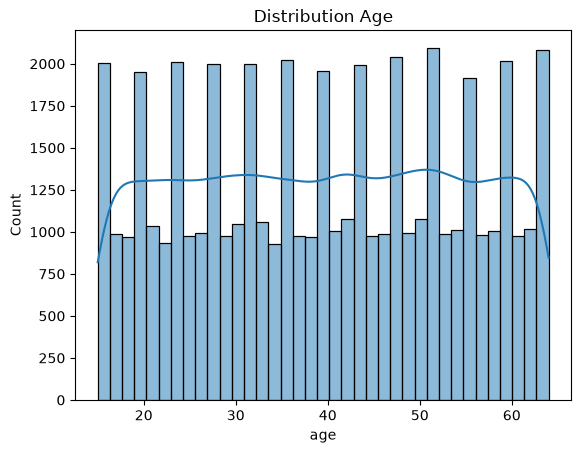

In [45]:
# Histogram kolom Age pada tabel users
sns.histplot(data=users,x='age',kde=True)
plt.title('Distribution Age')

Text(0.5, 1.0, 'Distribution Age')

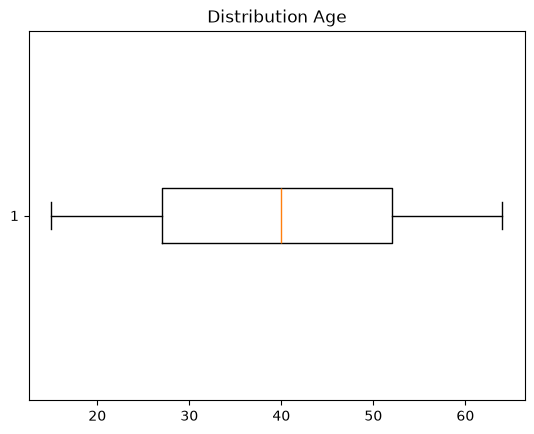

In [46]:
# Box Plot kolom Age pada tabel users
plt.boxplot(users['age'], orientation='horizontal')
plt.title('Distribution Age')

Text(0.5, 1.0, 'Users Count by Gender')

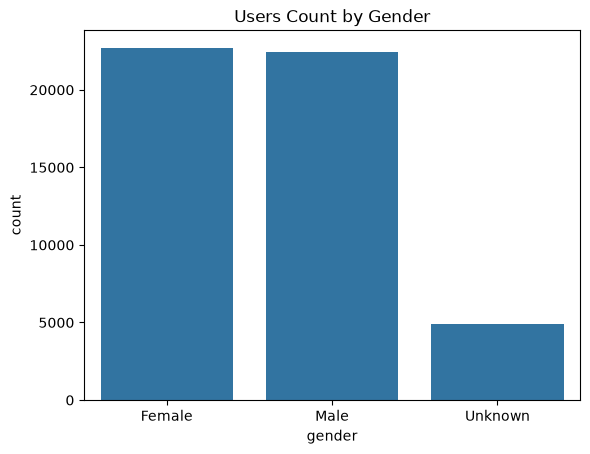

In [47]:
# Bar Plot kolom gender pada tabel Users
sns.countplot(data=users, x='gender', order=users['gender'].value_counts().index)
plt.title('Users Count by Gender')

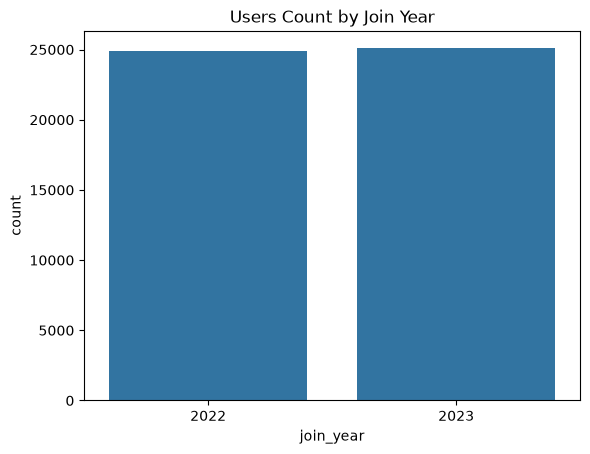

In [48]:
# Tren Users by Join Year
users['join_year']=users['join_date'].dt.year
sns.countplot(data=users, x='join_year')
plt.title('Users Count by Join Year')
plt.show()

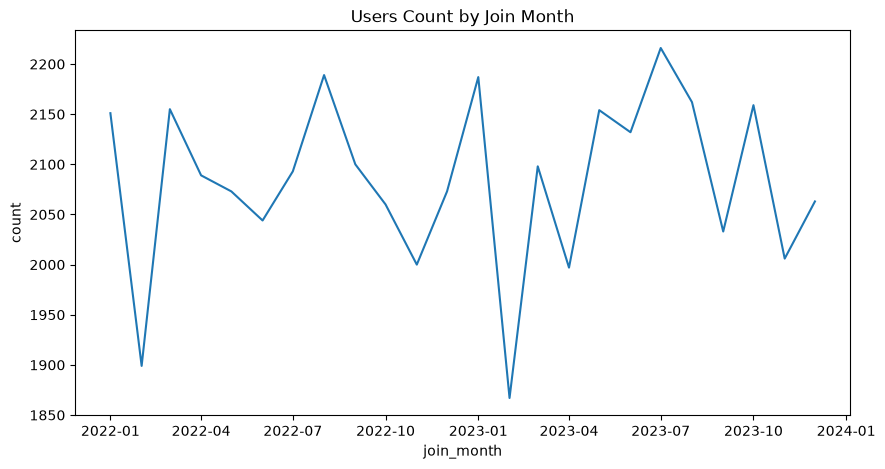

In [49]:
# Tren Users by Join Month
users['join_month']=users['join_date'].dt.to_period('M').dt.to_timestamp()

users_per_month=users.groupby('join_month').size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=users_per_month, x='join_month',y='count')
plt.title('Users Count by Join Month')
plt.show()

### **Tabel transactions_all**

In [50]:
users_transactions_all_new.info()

<class 'pandas.DataFrame'>
Index: 273658 entries, 0 to 299999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        273658 non-null  str           
 1   user_id         273658 non-null  str           
 2   order_date      273658 non-null  datetime64[us]
 3   payment_method  273658 non-null  str           
 4   promo_amount    273658 non-null  int64         
 5   total_amount    273658 non-null  int64         
 6   courier_name    273658 non-null  str           
 7   dispatch_date   273658 non-null  datetime64[us]
 8   delivery_date   273658 non-null  datetime64[us]
 9   join_date       273658 non-null  datetime64[us]
 10  gender          273658 non-null  str           
 11  location        273658 non-null  str           
 12  age             273658 non-null  int64         
dtypes: datetime64[us](4), int64(3), str(6)
memory usage: 40.9 MB


Text(0.5, 1.0, 'Order Count by Payment Method')

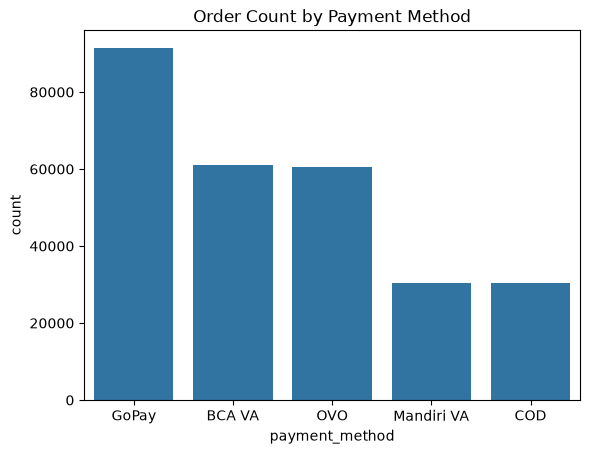

In [51]:
# Bar Plot kolom payment_method pada tabel users_transactions_all_new
sns.countplot(data=users_transactions_all_new, x='payment_method', order=users_transactions_all_new['payment_method'].value_counts().index)
plt.title('Order Count by Payment Method')

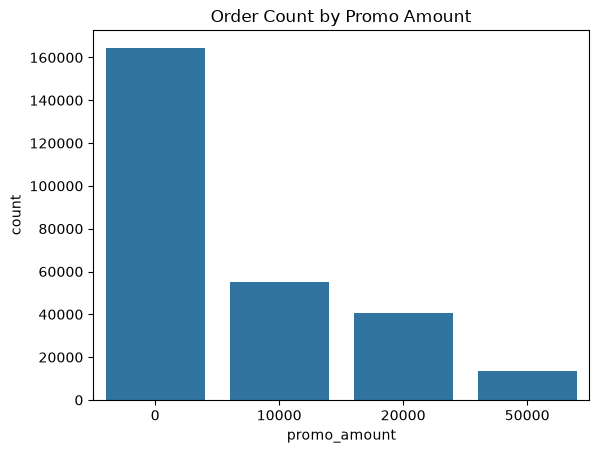

In [52]:
# Bar Plot kolom promo_amount pada tabel users_transactions_all_new
sns.countplot(data=users_transactions_all_new, x='promo_amount')
plt.title('Order Count by Promo Amount')
plt.show()

Text(0.5, 1.0, 'Order Count by Payment Method')

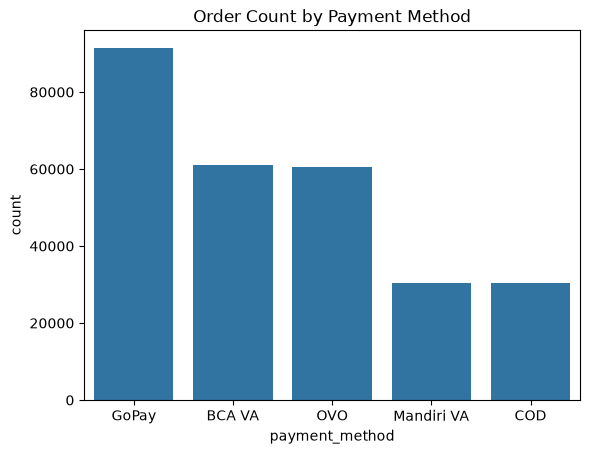

In [53]:
# Bar Plot kolom payment_method pada tabel transactions_all
sns.countplot(data=users_transactions_all_new, x='payment_method', order=users_transactions_all_new['payment_method'].value_counts().index)
plt.title('Order Count by Payment Method')

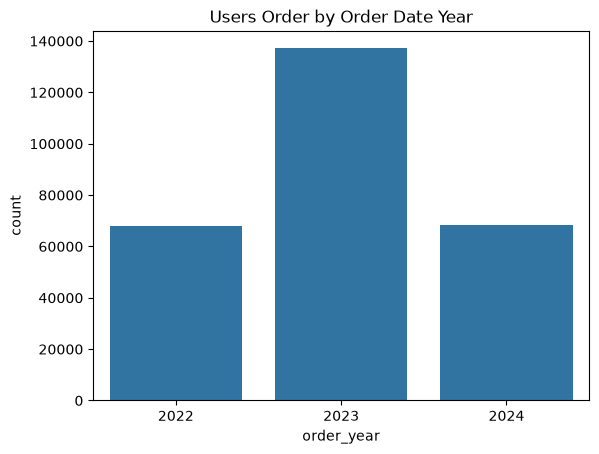

In [54]:
# Tren Users Order by Order Date Year
users_transactions_all_new['order_year']=users_transactions_all_new['order_date'].dt.year
sns.countplot(data=users_transactions_all_new, x='order_year')
plt.title('Users Order by Order Date Year')
plt.show()

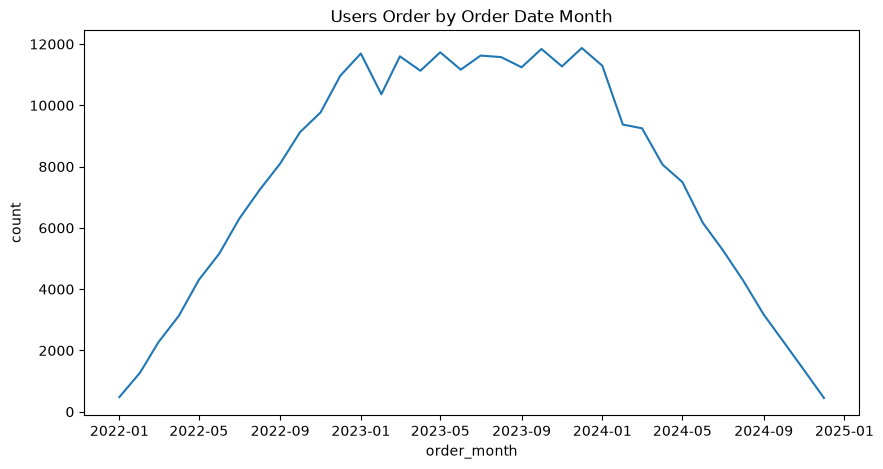

In [55]:
# Tren Users Order by Join Month
users_transactions_all_new['order_month']=users_transactions_all_new['order_date'].dt.to_period('M').dt.to_timestamp()

transactions_per_month=users_transactions_all_new.groupby('order_month').size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=transactions_per_month, x='order_month',y='count')
plt.title('Users Order by Order Date Month')
plt.show()

In [56]:
users_transactions_all_new.info()

<class 'pandas.DataFrame'>
Index: 273658 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        273658 non-null  str           
 1   user_id         273658 non-null  str           
 2   order_date      273658 non-null  datetime64[us]
 3   payment_method  273658 non-null  str           
 4   promo_amount    273658 non-null  int64         
 5   total_amount    273658 non-null  int64         
 6   courier_name    273658 non-null  str           
 7   dispatch_date   273658 non-null  datetime64[us]
 8   delivery_date   273658 non-null  datetime64[us]
 9   join_date       273658 non-null  datetime64[us]
 10  gender          273658 non-null  str           
 11  location        273658 non-null  str           
 12  age             273658 non-null  int64         
 13  order_year      273658 non-null  int32         
 14  order_month     273658 non-null  datetime64[us]
dtyp

# **Data Analysis**

## **1. Segmen user mana yang memiliki kecenderungan menjadi promo-hunter (hanya belanja saat ada promo lalu churn)?**

In [58]:
# Bikin tabel baru untuk amalisis promo hunter
# Tambah kolom baru untuk keterangan yang ada promo

promo_hunter_table=users_transactions_all_new.copy()
promo_hunter_table['has_promo']=np.where(promo_hunter_table['promo_amount']>0, 'Yes', 'No')

promo_hunter_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,has_promo
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-09-01,No
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-08-01,Yes
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2024,2024-05-01,No
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2024,2024-06-01,Yes
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2024,2024-03-01,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2024,2024-06-01,Yes
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2023,2023-02-01,No
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2023,2023-03-01,Yes
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2023,2023-04-01,Yes


In [59]:
# Tambah kolom jarak antarorder tiap user

promo_hunter_table=promo_hunter_table.sort_values(['user_id','order_date'])
promo_hunter_table['before_gap_days']=promo_hunter_table.groupby('user_id')['order_date'].diff().dt.days

promo_hunter_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,has_promo,before_gap_days
125581,ORD125582,USR00001,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,Yes,NaN
161333,ORD161334,USR00001,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,No,6.0
92272,ORD092273,USR00001,2023-01-23,BCA VA,0,1514092,SiCepat,2023-01-23,2023-01-26,2022-04-13,Female,Yogyakarta,21,2023,2023-01-01,No,237.0
224566,ORD224567,USR00002,2023-03-25,COD,20000,1528403,GoTo Logistics,2023-03-25,2023-03-27,2023-03-12,Female,Bandung,33,2023,2023-03-01,Yes,NaN
280223,ORD280224,USR00002,2023-04-28,BCA VA,0,423235,JNE,2023-04-28,2023-04-30,2023-03-12,Female,Bandung,33,2023,2023-04-01,No,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219366,ORD219367,USR50000,2023-11-01,BCA VA,0,962118,SiCepat,2023-11-02,2023-11-08,2023-06-29,Male,Jakarta,44,2023,2023-11-01,No,116.0
32821,ORD032822,USR50000,2023-11-24,OVO,0,156748,JNE,2023-11-24,2023-11-27,2023-06-29,Male,Jakarta,44,2023,2023-11-01,No,23.0
31174,ORD031175,USR50000,2024-02-04,BCA VA,0,1282068,AnterAja,2024-02-04,2024-02-06,2023-06-29,Male,Jakarta,44,2024,2024-02-01,No,72.0
91655,ORD091656,USR50000,2024-06-05,Mandiri VA,0,578235,JNE,2024-06-06,2024-06-11,2023-06-29,Male,Jakarta,44,2024,2024-06-01,No,122.0


In [60]:
promo_hunter_table['before_gap_days'].describe()

count    223874.000000
mean         52.047125
std          49.223833
min           0.000000
25%          15.000000
50%          37.000000
75%          74.000000
max         359.000000
Name: before_gap_days, dtype: float64

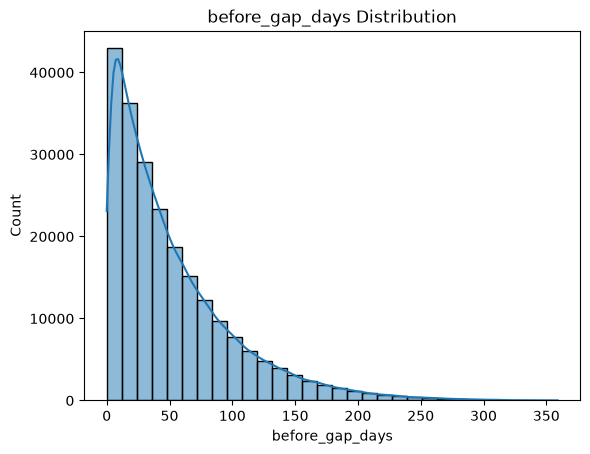

In [61]:
# Tampilkan histogram before_gap_days

sns.histplot(promo_hunter_table['before_gap_days'], bins=30, kde=True)
plt.title('before_gap_days Distribution')
plt.show()

In [62]:
# Tabel transaksi per user

user_detail=promo_hunter_table.groupby('user_id').agg(
    count_order=('order_id', 'count'),
    count_promo=('has_promo', lambda p: (p=='Yes').sum()),
    total_promo=('promo_amount', 'sum'),
    avg_gmv=('total_amount', 'mean'),
    median_gap=('before_gap_days','median'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
    gender=('gender', 'first'),
    location=('location', 'first'),
    ).reset_index()

user_detail

,user_id,count_order,count_promo,total_promo,avg_gmv,median_gap,first_order,last_order,gender,location
0,USR00001,3,1,20000,1.342353e+06,121.5,2022-05-25,2023-01-23,Female,Yogyakarta
1,USR00002,7,4,60000,8.514370e+05,34.0,2023-03-25,2024-01-17,Female,Bandung
2,USR00003,4,1,10000,8.525035e+05,89.0,2022-10-25,2023-09-20,Female,Bandung
3,USR00004,9,8,190000,9.630587e+05,26.5,2022-05-15,2023-03-29,Female,Bandung
4,USR00005,6,3,80000,7.390120e+05,52.0,2022-06-30,2023-01-24,Female,Bandung
...,...,...,...,...,...,...,...,...,...,...
49779,USR49996,6,3,40000,7.967498e+05,48.0,2022-09-04,2023-08-30,Male,Medan
49780,USR49997,7,2,20000,1.003867e+06,33.5,2022-08-14,2023-03-29,Unknown,Surabaya
49781,USR49998,8,4,100000,1.223636e+06,45.0,2023-03-02,2024-01-16,Male,Yogyakarta
49782,USR49999,5,4,50000,9.430172e+05,32.0,2022-10-12,2023-04-21,Male,Makassar


Asumsikan jika churn apabila median jarak antarorder tiap user > 90 hari.<br>
Asumsikan jika promo-hunter apabila penggunaan promo lebih dari 80% order.

In [63]:
user_detail['churn']=np.where(user_detail['median_gap']>90, 'Yes', 'No')
user_detail['persen_promo']=user_detail['count_promo']/user_detail['count_order']*100
user_detail['promo_hunter']=np.where(
    (user_detail['churn']=='No')&
    (user_detail['persen_promo']>80),
    'Yes', 'No')

user_detail

,user_id,count_order,count_promo,total_promo,avg_gmv,median_gap,first_order,last_order,gender,location,churn,persen_promo,promo_hunter
0,USR00001,3,1,20000,1.342353e+06,121.5,2022-05-25,2023-01-23,Female,Yogyakarta,Yes,33.333333,No
1,USR00002,7,4,60000,8.514370e+05,34.0,2023-03-25,2024-01-17,Female,Bandung,No,57.142857,No
2,USR00003,4,1,10000,8.525035e+05,89.0,2022-10-25,2023-09-20,Female,Bandung,No,25.000000,No
3,USR00004,9,8,190000,9.630587e+05,26.5,2022-05-15,2023-03-29,Female,Bandung,No,88.888889,Yes
4,USR00005,6,3,80000,7.390120e+05,52.0,2022-06-30,2023-01-24,Female,Bandung,No,50.000000,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49779,USR49996,6,3,40000,7.967498e+05,48.0,2022-09-04,2023-08-30,Male,Medan,No,50.000000,No
49780,USR49997,7,2,20000,1.003867e+06,33.5,2022-08-14,2023-03-29,Unknown,Surabaya,No,28.571429,No
49781,USR49998,8,4,100000,1.223636e+06,45.0,2023-03-02,2024-01-16,Male,Yogyakarta,No,50.000000,No
49782,USR49999,5,4,50000,9.430172e+05,32.0,2022-10-12,2023-04-21,Male,Makassar,No,80.000000,No


In [64]:
promo_segmen_gender=pd.crosstab(user_detail['gender'], user_detail['promo_hunter'])
promo_segmen_gender

promo_hunter,No,Yes
gender,,
Female,21863,731
Male,21570,751
Unknown,4714,155


In [65]:
promo_segmen_gender['Total']=promo_segmen_gender['No']+promo_segmen_gender['Yes']
promo_segmen_gender['Promo_Hunter_Rate']=promo_segmen_gender['Yes']/promo_segmen_gender['Total']*100
promo_segmen_gender

promo_hunter,No,Yes,Total,Promo_Hunter_Rate
gender,,,,
Female,21863,731,22594,3.235372
Male,21570,751,22321,3.364545
Unknown,4714,155,4869,3.183405


`Hipotesis` :
    
$H_{0}$ : `promo_hunter	` dan `gender` independent

$H_{a}$ : `promo_hunter	` dan `gender` dependent

`Signifikansi/level of risk` $\rightarrow \alpha=0.05$

`Rejection Criteria`:
- p-value $\leq 0.05$ : Reject $H_{0}$
- p-value $> 0.05$ : Failed to Reject $H_{0}$

In [66]:
from scipy.stats import chi2_contingency

p_val=chi2_contingency(promo_segmen_gender)[1]

if p_val <= 0.05:
    print(f"p-value = {p_val} ≤ 0.05, maka menurut uji chi square variabel promo_hunter dab gender dependent atau saling berhubungan")
else:
    print(f"p-value = {p_val} > 0.05, maka menurut uji chi square variabel promo_hunter dab gender independent atau tidak saling berhubungan")

p-value = 0.36752585334637017 > 0.05, maka menurut uji chi square variabel promo_hunter dab gender independent atau tidak saling berhubungan


In [67]:
promo_segmen_location=pd.crosstab(user_detail['location'], user_detail['promo_hunter'])
promo_segmen_location

promo_hunter,No,Yes
location,,
Bandung,8004,270
Jakarta,7994,272
Makassar,8062,293
Medan,8055,228
Surabaya,8102,296
Yogyakarta,7930,278


In [68]:
promo_segmen_location['Total']=promo_segmen_location['No']+promo_segmen_location['Yes']
promo_segmen_location['Promo_Hunter_Rate']=promo_segmen_location['Yes']/promo_segmen_location['Total']*100
promo_segmen_location

promo_hunter,No,Yes,Total,Promo_Hunter_Rate
location,,,,
Bandung,8004,270,8274,3.263234
Jakarta,7994,272,8266,3.290588
Makassar,8062,293,8355,3.506882
Medan,8055,228,8283,2.752626
Surabaya,8102,296,8398,3.524649
Yogyakarta,7930,278,8208,3.386940


`Hipotesis` :
    
$H_{0}$ : `promo_hunter	` dan `location` independent

$H_{a}$ : `promo_hunter	` dan `location` dependent

`Signifikansi/level of risk` $\rightarrow \alpha=0.05$

`Rejection Criteria`:
- p-value $\leq 0.05$ : Reject $H_{0}$
- p-value $> 0.05$ : Failed to Reject $H_{0}$

In [69]:
from scipy.stats import chi2_contingency

p_val=chi2_contingency(promo_segmen_location)[1]

if p_val <= 0.05:
    print(f"p-value = {p_val} ≤ 0.05, maka menurut uji chi square variabel promo_hunter dan location dependent atau saling berhubungan")
else:
    print(f"p-value = {p_val} > 0.05, maka menurut uji chi square variabel promo_hunter dan location independent atau tidak saling berhubungan")

p-value = 0.7813092285199479 > 0.05, maka menurut uji chi square variabel promo_hunter dan location independent atau tidak saling berhubungan


**Kesimpulan No. 1:**<br>
Segmen promo hunter promo relatif tersebar merata, berada di sekitaran 3%. Tidak ada perbedaan pada segmen gender. Berdasarkan lokasi user, Surabaya (3,52%) dan Makassar (3,51%) cenderung tinggi, namun selisih dengan kota lainnya masih kecil. Karakteristik promo hunter mungkin lebih terlihat dari perilaku user seperti frekuensi order.

## **2. Seberapa besar dampak keterlambatan pengiriman (SLA miss) terhadap kemungkinan user melakukan repeat order?**

In [141]:
users_transactions_all_new

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-09-01
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-08-01
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2024,2024-05-01
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2024,2024-06-01
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2024,2024-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2024,2024-06-01
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2023,2023-02-01
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2023,2023-03-01
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2023,2023-04-01


SLA pengiriman dihitung dari tanggal order (`order_date`) sampai barang diterima oleh penerim (delivery_date`). Diasumsikan standar SLA-nya adalah 3 hari.

In [71]:
# Atur SLA pengiriman = 3
SLA_days=3

SLA_table=users_transactions_all_new.copy()
SLA_table['delivery_days']=(SLA_table['delivery_date']-SLA_table['order_date']).dt.days
SLA_table['SLA_miss']=SLA_table.apply(lambda s: 'Yes' if s['delivery_days']>SLA_days else 'No', axis=1)

SLA_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,delivery_days,SLA_miss
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-09-01,4,Yes
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-08-01,6,Yes
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2024,2024-05-01,5,Yes
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2024,2024-06-01,5,Yes
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2024,2024-03-01,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2024,2024-06-01,6,Yes
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2023,2023-02-01,3,No
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2023,2023-03-01,5,Yes
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2023,2023-04-01,6,Yes


In [72]:
SLA_table=SLA_table.sort_values(['user_id','order_date'],ascending=True)

# Membuat kolom next order
SLA_table['next_order']=SLA_table.groupby('user_id')['order_date'].shift(-1)

SLA_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,delivery_days,SLA_miss,next_order
125581,ORD125582,USR00001,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2022-05-31
161333,ORD161334,USR00001,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2023-01-23
92272,ORD092273,USR00001,2023-01-23,BCA VA,0,1514092,SiCepat,2023-01-23,2023-01-26,2022-04-13,Female,Yogyakarta,21,2023,2023-01-01,3,No,NaT
224566,ORD224567,USR00002,2023-03-25,COD,20000,1528403,GoTo Logistics,2023-03-25,2023-03-27,2023-03-12,Female,Bandung,33,2023,2023-03-01,2,No,2023-04-28
280223,ORD280224,USR00002,2023-04-28,BCA VA,0,423235,JNE,2023-04-28,2023-04-30,2023-03-12,Female,Bandung,33,2023,2023-04-01,2,No,2023-05-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219366,ORD219367,USR50000,2023-11-01,BCA VA,0,962118,SiCepat,2023-11-02,2023-11-08,2023-06-29,Male,Jakarta,44,2023,2023-11-01,7,Yes,2023-11-24
32821,ORD032822,USR50000,2023-11-24,OVO,0,156748,JNE,2023-11-24,2023-11-27,2023-06-29,Male,Jakarta,44,2023,2023-11-01,3,No,2024-02-04
31174,ORD031175,USR50000,2024-02-04,BCA VA,0,1282068,AnterAja,2024-02-04,2024-02-06,2023-06-29,Male,Jakarta,44,2024,2024-02-01,2,No,2024-06-05
91655,ORD091656,USR50000,2024-06-05,Mandiri VA,0,578235,JNE,2024-06-06,2024-06-11,2023-06-29,Male,Jakarta,44,2024,2024-06-01,6,Yes,2024-06-19


In [73]:
# Diasumsikan user repeat order jika order kembali dalam waktu 30 hari setelah barang sampai
gap_order_days=(SLA_table['next_order']-SLA_table['delivery_date']).dt.days
SLA_table['repeat_order']=np.where((gap_order_days>=0)&(gap_order_days<=30), 'Yes', 'No')

SLA_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,delivery_days,SLA_miss,next_order,repeat_order
125581,ORD125582,USR00001,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2022-05-31,Yes
161333,ORD161334,USR00001,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2023-01-23,No
92272,ORD092273,USR00001,2023-01-23,BCA VA,0,1514092,SiCepat,2023-01-23,2023-01-26,2022-04-13,Female,Yogyakarta,21,2023,2023-01-01,3,No,NaT,No
224566,ORD224567,USR00002,2023-03-25,COD,20000,1528403,GoTo Logistics,2023-03-25,2023-03-27,2023-03-12,Female,Bandung,33,2023,2023-03-01,2,No,2023-04-28,No
280223,ORD280224,USR00002,2023-04-28,BCA VA,0,423235,JNE,2023-04-28,2023-04-30,2023-03-12,Female,Bandung,33,2023,2023-04-01,2,No,2023-05-09,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219366,ORD219367,USR50000,2023-11-01,BCA VA,0,962118,SiCepat,2023-11-02,2023-11-08,2023-06-29,Male,Jakarta,44,2023,2023-11-01,7,Yes,2023-11-24,Yes
32821,ORD032822,USR50000,2023-11-24,OVO,0,156748,JNE,2023-11-24,2023-11-27,2023-06-29,Male,Jakarta,44,2023,2023-11-01,3,No,2024-02-04,No
31174,ORD031175,USR50000,2024-02-04,BCA VA,0,1282068,AnterAja,2024-02-04,2024-02-06,2023-06-29,Male,Jakarta,44,2024,2024-02-01,2,No,2024-06-05,No
91655,ORD091656,USR50000,2024-06-05,Mandiri VA,0,578235,JNE,2024-06-06,2024-06-11,2023-06-29,Male,Jakarta,44,2024,2024-06-01,6,Yes,2024-06-19,Yes


In [74]:
SLA_table['order_date'].max()

Timestamp('2024-12-28 00:00:00')

Filter data yang delivery_date + 30 hari <= dari SLA_table['order_date'].max()

In [75]:
SLA_table=SLA_table[SLA_table['delivery_date']+pd.Timedelta(days=30)<=SLA_table['order_date'].max()]

SLA_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,delivery_days,SLA_miss,next_order,repeat_order
125581,ORD125582,USR00001,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2022-05-31,Yes
161333,ORD161334,USR00001,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2023-01-23,No
92272,ORD092273,USR00001,2023-01-23,BCA VA,0,1514092,SiCepat,2023-01-23,2023-01-26,2022-04-13,Female,Yogyakarta,21,2023,2023-01-01,3,No,NaT,No
224566,ORD224567,USR00002,2023-03-25,COD,20000,1528403,GoTo Logistics,2023-03-25,2023-03-27,2023-03-12,Female,Bandung,33,2023,2023-03-01,2,No,2023-04-28,No
280223,ORD280224,USR00002,2023-04-28,BCA VA,0,423235,JNE,2023-04-28,2023-04-30,2023-03-12,Female,Bandung,33,2023,2023-04-01,2,No,2023-05-09,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219366,ORD219367,USR50000,2023-11-01,BCA VA,0,962118,SiCepat,2023-11-02,2023-11-08,2023-06-29,Male,Jakarta,44,2023,2023-11-01,7,Yes,2023-11-24,Yes
32821,ORD032822,USR50000,2023-11-24,OVO,0,156748,JNE,2023-11-24,2023-11-27,2023-06-29,Male,Jakarta,44,2023,2023-11-01,3,No,2024-02-04,No
31174,ORD031175,USR50000,2024-02-04,BCA VA,0,1282068,AnterAja,2024-02-04,2024-02-06,2023-06-29,Male,Jakarta,44,2024,2024-02-01,2,No,2024-06-05,No
91655,ORD091656,USR50000,2024-06-05,Mandiri VA,0,578235,JNE,2024-06-06,2024-06-11,2023-06-29,Male,Jakarta,44,2024,2024-06-01,6,Yes,2024-06-19,Yes


In [76]:
SLA_table.info()

<class 'pandas.DataFrame'>
Index: 272986 entries, 125581 to 211565
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        272986 non-null  str           
 1   user_id         272986 non-null  str           
 2   order_date      272986 non-null  datetime64[us]
 3   payment_method  272986 non-null  str           
 4   promo_amount    272986 non-null  int64         
 5   total_amount    272986 non-null  int64         
 6   courier_name    272986 non-null  str           
 7   dispatch_date   272986 non-null  datetime64[us]
 8   delivery_date   272986 non-null  datetime64[us]
 9   join_date       272986 non-null  datetime64[us]
 10  gender          272986 non-null  str           
 11  location        272986 non-null  str           
 12  age             272986 non-null  int64         
 13  order_year      272986 non-null  int32         
 14  order_month     272986 non-null  datetime64[us]

In [77]:
SLA_table.dropna(inplace=True)

In [78]:
SLA_table.info()

<class 'pandas.DataFrame'>
Index: 223762 entries, 125581 to 91655
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        223762 non-null  str           
 1   user_id         223762 non-null  str           
 2   order_date      223762 non-null  datetime64[us]
 3   payment_method  223762 non-null  str           
 4   promo_amount    223762 non-null  int64         
 5   total_amount    223762 non-null  int64         
 6   courier_name    223762 non-null  str           
 7   dispatch_date   223762 non-null  datetime64[us]
 8   delivery_date   223762 non-null  datetime64[us]
 9   join_date       223762 non-null  datetime64[us]
 10  gender          223762 non-null  str           
 11  location        223762 non-null  str           
 12  age             223762 non-null  int64         
 13  order_year      223762 non-null  int32         
 14  order_month     223762 non-null  datetime64[us]


In [79]:
SLA_table.drop_duplicates(inplace=True)
SLA_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,order_year,order_month,delivery_days,SLA_miss,next_order,repeat_order
125581,ORD125582,USR00001,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2022-05-31,Yes
161333,ORD161334,USR00001,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,2022-04-13,Female,Yogyakarta,21,2022,2022-05-01,4,Yes,2023-01-23,No
224566,ORD224567,USR00002,2023-03-25,COD,20000,1528403,GoTo Logistics,2023-03-25,2023-03-27,2023-03-12,Female,Bandung,33,2023,2023-03-01,2,No,2023-04-28,No
280223,ORD280224,USR00002,2023-04-28,BCA VA,0,423235,JNE,2023-04-28,2023-04-30,2023-03-12,Female,Bandung,33,2023,2023-04-01,2,No,2023-05-09,Yes
146829,ORD146830,USR00002,2023-05-09,GoPay,10000,104440,AnterAja,2023-05-09,2023-05-13,2023-03-12,Female,Bandung,33,2023,2023-05-01,4,Yes,2023-10-12,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45663,ORD045664,USR50000,2023-07-08,Mandiri VA,10000,151876,GoTo Logistics,2023-07-10,2023-07-15,2023-06-29,Male,Jakarta,44,2023,2023-07-01,7,Yes,2023-11-01,No
219366,ORD219367,USR50000,2023-11-01,BCA VA,0,962118,SiCepat,2023-11-02,2023-11-08,2023-06-29,Male,Jakarta,44,2023,2023-11-01,7,Yes,2023-11-24,Yes
32821,ORD032822,USR50000,2023-11-24,OVO,0,156748,JNE,2023-11-24,2023-11-27,2023-06-29,Male,Jakarta,44,2023,2023-11-01,3,No,2024-02-04,No
31174,ORD031175,USR50000,2024-02-04,BCA VA,0,1282068,AnterAja,2024-02-04,2024-02-06,2023-06-29,Male,Jakarta,44,2024,2024-02-01,2,No,2024-06-05,No


In [80]:
SLA_table.corr(numeric_only=True)

,promo_amount,total_amount,age,order_year,delivery_days
promo_amount,1.000000,-0.002141,0.000404,0.001577,-0.000453
total_amount,-0.002141,1.000000,-0.003851,0.005671,0.006558
age,0.000404,-0.003851,1.000000,0.002188,-0.000697
order_year,0.001577,0.005671,0.002188,1.000000,-0.001329
delivery_days,-0.000453,0.006558,-0.000697,-0.001329,1.000000


In [81]:
SLA_repeat=pd.crosstab(SLA_table['SLA_miss'], SLA_table['repeat_order'])
SLA_repeat

repeat_order,No,Yes
SLA_miss,,
No,42981,31925
Yes,89293,59563


In [82]:
SLA_repeat['Total']=SLA_repeat['No']+SLA_repeat['Yes']
SLA_repeat['Repeat_Rate']=SLA_repeat['Yes']/SLA_repeat['Total']*100
SLA_repeat

repeat_order,No,Yes,Total,Repeat_Rate
SLA_miss,,,,
No,42981,31925,74906,42.620084
Yes,89293,59563,148856,40.013839


`Hipotesis` :
    
$H_{0}$ : `repeat_order` dan `SLA_miss` independent

$H_{a}$ : `repeat_order` dan `SLA_miss` dependent

`Signifikansi/level of risk` $\rightarrow \alpha=0.05$

`Rejection Criteria`:
- p-value $\leq 0.05$ : Reject $H_{0}$
- p-value $> 0.05$ : Failed to Reject $H_{0}$

In [83]:
from scipy.stats import chi2_contingency

p_val=chi2_contingency(SLA_repeat)[1]

if p_val <= 0.05:
    print(f"p-value = {p_val} ≤ 0.05, maka menurut uji chi square variabel repeat order dab SLA_miss dependent atau saling berhubungan")
else:
    print(f"p-value = {p_val} > 0.05, maka menurut uji chi square variabel repeat order dab SLA_miss independent atau tidak saling berhubungan")


p-value = 8.872875056269424e-33 ≤ 0.05, maka menurut uji chi square variabel repeat order dab SLA_miss dependent atau saling berhubungan


**Kesimpulan No. 2:**<br>
Ada dampak SLA miss (Pengiriman lebih dari 3 hari) ke repeat order namun hanya kecil. Pengiriman yang terlambat (SLA miss) memiliki peluang repeat order sebesar 40,01%. Pengiriman tepat waktu (SLA tidak miss) memiliki peluang repeat order sebesar 42,62%. Perbedaan peluang repea order dari pengiriman tepat waktu dan terlambat hanya 2% saja.

## **3. Metode pembayaran apa yang paling sering mengalami anomali transaksi atau drop-off?**

In [84]:
# Membuat tabel baru untuk analisis lebih lanjut
anomali_table=transactions_all.merge(users, on='user_id', how='left')
display(anomali_table)

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-07-01
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-01-01
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2023,2023-07-01
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2023,2023-06-01
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2023,2023-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2023,2023-08-01
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2022,2022-07-01
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2022,2022-05-01
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2022,2022-12-01


In [85]:
# Filter data transaksi yang join_date <= order_date saja

anomali_table=anomali_table[anomali_table['join_date']<=anomali_table['order_date']]
anomali_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-07-01
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-01-01
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2023,2023-07-01
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2023,2023-06-01
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2023,2023-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2023,2023-08-01
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2022,2022-07-01
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2022,2022-05-01
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2022,2022-12-01


In [86]:
display(anomali_table.isna().sum())
display(anomali_table.info())

order_id          0
user_id           0
order_date        0
payment_method    0
promo_amount      0
total_amount      0
courier_name      0
dispatch_date     0
delivery_date     0
join_date         0
gender            0
location          0
age               0
join_year         0
join_month        0
dtype: int64

<class 'pandas.DataFrame'>
Index: 285000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        285000 non-null  str           
 1   user_id         285000 non-null  str           
 2   order_date      285000 non-null  datetime64[us]
 3   payment_method  285000 non-null  str           
 4   promo_amount    285000 non-null  int64         
 5   total_amount    285000 non-null  int64         
 6   courier_name    285000 non-null  str           
 7   dispatch_date   285000 non-null  datetime64[us]
 8   delivery_date   285000 non-null  datetime64[us]
 9   join_date       285000 non-null  datetime64[us]
 10  gender          285000 non-null  str           
 11  location        285000 non-null  str           
 12  age             285000 non-null  int64         
 13  join_year       285000 non-null  int32         
 14  join_month      285000 non-null  datetime64[us]
dtyp

None

In [87]:
anomali_table.drop_duplicates(inplace=True)

In [88]:
# Tambah kolom untuk menandai transaksi yang anomali
anomali_table['amount_invalid']=np.where(anomali_table['promo_amount']>anomali_table['total_amount'],'Yes','No')

# Tambal kolom untuk menandai delivery yang anomali
anomali_table['delivery_invalid']=np.where(
    (anomali_table['order_date']<=anomali_table['dispatch_date'])&
    (anomali_table['dispatch_date']<=anomali_table['delivery_date']),'No','Yes')

anomali_table

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month,amount_invalid,delivery_invalid
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-07-01,No,No
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-01-01,No,No
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2023,2023-07-01,No,No
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2023,2023-06-01,No,No
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2023,2023-07-01,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2023,2023-08-01,No,No
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2022,2022-07-01,No,No
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2022,2022-05-01,No,No
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2022,2022-12-01,No,No


In [89]:
display(anomali_table['amount_invalid'].value_counts())
display(anomali_table['delivery_invalid'].value_counts())

amount_invalid
No     282114
Yes      2886
Name: count, dtype: int64

delivery_invalid
No     276460
Yes      8540
Name: count, dtype: int64

In [90]:
anomali_payment_delivery=anomali_table.groupby('payment_method').agg(
    total_order=('order_id','count'),
    total_amount_invalid=('amount_invalid', lambda s: (s=='Yes').sum()),
    total_delivery_invalid=('delivery_invalid', lambda s: (s=='Yes').sum()))

anomali_payment_delivery

,total_order,total_amount_invalid,total_delivery_invalid
payment_method,,,
BCA VA,63488,617,1916
COD,31662,331,951
GoPay,95194,954,2846
Mandiri VA,31636,313,909
OVO,63020,671,1918


In [91]:
anomali_payment_delivery['persen_amount_invalid']=anomali_payment_delivery['total_amount_invalid']/anomali_payment_delivery['total_order']*100
anomali_payment_delivery['persen_delivery_invalid']=anomali_payment_delivery['total_delivery_invalid']/anomali_payment_delivery['total_order']*100

anomali_payment_delivery

,total_order,total_amount_invalid,total_delivery_invalid,persen_amount_invalid,persen_delivery_invalid
payment_method,,,,,
BCA VA,63488,617,1916,0.971837,3.017893
COD,31662,331,951,1.045417,3.003601
GoPay,95194,954,2846,1.002164,2.989684
Mandiri VA,31636,313,909,0.989379,2.873309
OVO,63020,671,1918,1.064741,3.043478


In [92]:
# Tambah kolom lift hasil perbandingan dengan rata-rata keseluruhan

persen_total_amount_invalid=((anomali_table['amount_invalid']=='Yes').mean())*100
anomali_payment_delivery['lift_amount_invalid']=anomali_payment_delivery['persen_amount_invalid']/persen_total_amount_invalid

persen_total_delivery_invalid=((anomali_table['delivery_invalid']=='Yes').mean())*100
anomali_payment_delivery['lift_delivery_invalid']=anomali_payment_delivery['persen_delivery_invalid']/persen_total_delivery_invalid

anomali_payment_delivery

,total_order,total_amount_invalid,total_delivery_invalid,persen_amount_invalid,persen_delivery_invalid,lift_amount_invalid,lift_delivery_invalid
payment_method,,,,,,,
BCA VA,63488,617,1916,0.971837,3.017893,0.959714,1.007142
COD,31662,331,951,1.045417,3.003601,1.032377,1.002373
GoPay,95194,954,2846,1.002164,2.989684,0.989663,0.997728
Mandiri VA,31636,313,909,0.989379,2.873309,0.977038,0.958891
OVO,63020,671,1918,1.064741,3.043478,1.051460,1.015681


Dari tabel `anomali_payment_delivery`, diperoleh beberapa hal sebagai berikut.
1. Nilai lift berdasarkan data anomali total amount, payment_method yang bermasalah lebih buruk dari rata-rata adalah payment_method `COD` dan `OVO`. <br>
2. Nilai lift berdasarkan data anomali total amount, payment_method yang bermasalah lebih baik dari rata-rata adalah payment_method `BCA VA`, `GoPay`, dan `Mandiri VA`. <br>
3. Nilai lift berdasarkan data anomali tanggal pengiriman, payment_method yang bermasalah lebih buruk dari rata-rata adalah payment_method `BCA VA`, `COD`, dan `OVO`. <br>
4. Nilai lift berdasarkan data anomali tanggal pengiriman, payment_method yang bermasalah lebih baik dari rata-rata adalah payment_method `GoPay` dan `Mandiri VA`.

**Uji Statistika untuk mengecek hubungan `payment_method` dan `amount_invalid`**

In [93]:
anomali_amount_check=pd.crosstab(anomali_table['payment_method'],anomali_table['amount_invalid'])

anomali_amount_check

amount_invalid,No,Yes
payment_method,,
BCA VA,62871,617
COD,31331,331
GoPay,94240,954
Mandiri VA,31323,313
OVO,62349,671


In [94]:
anomali_amount_check['Total']=anomali_amount_check['No']+anomali_amount_check['Yes']
anomali_amount_check['Amount_Rate']=anomali_amount_check['Yes']/anomali_amount_check['Total']*100
anomali_amount_check

amount_invalid,No,Yes,Total,Amount_Rate
payment_method,,,,
BCA VA,62871,617,63488,0.971837
COD,31331,331,31662,1.045417
GoPay,94240,954,95194,1.002164
Mandiri VA,31323,313,31636,0.989379
OVO,62349,671,63020,1.064741


`Hipotesis` :
    
$H_{0}$ : `payment_method` dan `amount_invalid` independent

$H_{a}$ : `payment_method` dan `amount_invalid` dependent

`Signifikansi/level of risk` $\rightarrow \alpha=0.05$

`Rejection Criteria`:
- p-value $\leq 0.05$ : Reject $H_{0}$
- p-value $> 0.05$ : Failed to Reject $H_{0}$

In [95]:
from scipy.stats import chi2_contingency

p_val=chi2_contingency(anomali_amount_check)[1]

if p_val <= 0.05:
    print(f"p-value = {p_val} ≤ 0.05, maka menurut uji chi square variabel payment_method dan amount_invalid dependent atau saling berhubungan")
else:
    print(f"p-value = {p_val} > 0.05, maka menurut uji chi square variabel payment_method dan amount_invalid independent atau tidak saling berhubungan")


p-value = 0.9746629682079005 > 0.05, maka menurut uji chi square variabel payment_method dan amount_invalid independent atau tidak saling berhubungan


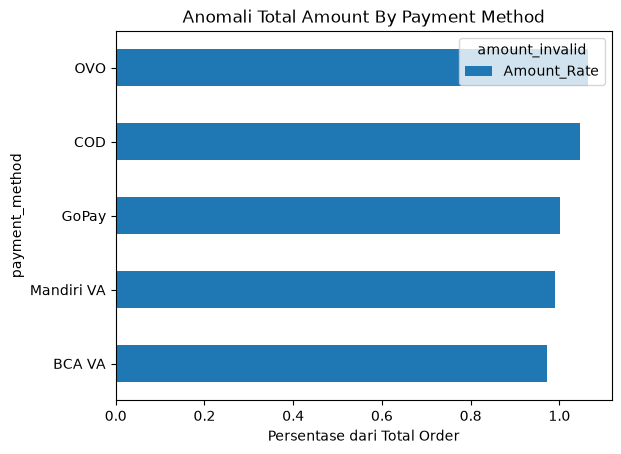

In [96]:
plt.figsize=(10,5)
anomali_amount_check[['Amount_Rate']].sort_values('Amount_Rate').plot(
    kind='barh', title='Anomali Total Amount By Payment Method')
plt.xlabel('Persentase dari Total Order')
plt.show()

**Uji Statistika untuk mengecek hubungan `payment_method` dan `delivery_invalid`**

In [97]:
anomali_delivery_check=pd.crosstab(anomali_table['payment_method'],anomali_table['delivery_invalid'])

anomali_delivery_check

delivery_invalid,No,Yes
payment_method,,
BCA VA,61572,1916
COD,30711,951
GoPay,92348,2846
Mandiri VA,30727,909
OVO,61102,1918


In [98]:
anomali_delivery_check['Total']=anomali_delivery_check['No']+anomali_delivery_check['Yes']
anomali_delivery_check['Delivery_Rate']=anomali_delivery_check['Yes']/anomali_delivery_check['Total']*100
anomali_delivery_check

delivery_invalid,No,Yes,Total,Delivery_Rate
payment_method,,,,
BCA VA,61572,1916,63488,3.017893
COD,30711,951,31662,3.003601
GoPay,92348,2846,95194,2.989684
Mandiri VA,30727,909,31636,2.873309
OVO,61102,1918,63020,3.043478


`Hipotesis` :
    
$H_{0}$ : `payment_method` dan `delivery_invalid` independent

$H_{a}$ : `payment_method` dan `delivery_invalid` dependent

`Signifikansi/level of risk` $\rightarrow \alpha=0.05$

`Rejection Criteria`:
- p-value $\leq 0.05$ : Reject $H_{0}$
- p-value $> 0.05$ : Failed to Reject $H_{0}$

In [99]:
from scipy.stats import chi2_contingency

p_val=chi2_contingency(anomali_amount_check)[1]

if p_val <= 0.05:
    print(f"p-value = {p_val} ≤ 0.05, maka menurut uji chi square variabel payment_method dan delivery_invalid dependent atau saling berhubungan")
else:
    print(f"p-value = {p_val} > 0.05, maka menurut uji chi square variabel payment_method dan delivery_invalid independent atau tidak saling berhubungan")


p-value = 0.9746629682079005 > 0.05, maka menurut uji chi square variabel payment_method dan delivery_invalid independent atau tidak saling berhubungan


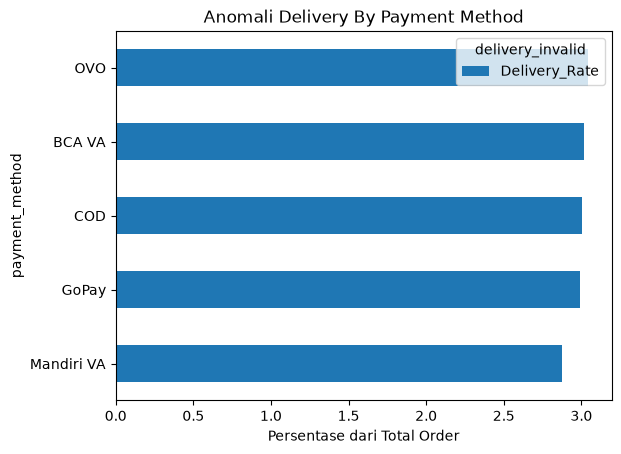

In [100]:
plt.figsize=(10,5)
anomali_delivery_check[['Delivery_Rate']].sort_values('Delivery_Rate').plot(
    kind='barh', title='Anomali Delivery By Payment Method')
plt.xlabel('Persentase dari Total Order')
plt.show()

**Kesimpulan No. 3:**<br>
Ada anomali tiap metode pembayaran namun relatif sama.Tingkat anomali transaksi di tiap metode pembayaran berada di sekitaran angka 1% untuk anomali nilai total transaksi (nilai promo > nilai transaksi). Tingkat anomali transaksi di tiap metode pembayaran berada di sekitaran 3% untuk anomali tanggal transaksi yang tidak sesuai.

## **4. Bagaimana korelasi antara lokasi user dan durasi pengiriman terhadap total nilai transaksi (GMV)?**

In [101]:
corr_gmv_table=SLA_table[['user_id', 'location', 'delivery_days', 'total_amount']]
corr_gmv_table

,user_id,location,delivery_days,total_amount
125581,USR00001,Yogyakarta,4,1423356
161333,USR00001,Yogyakarta,4,1089610
224566,USR00002,Bandung,2,1528403
280223,USR00002,Bandung,2,423235
146829,USR00002,Bandung,4,104440
...,...,...,...,...
45663,USR50000,Jakarta,7,151876
219366,USR50000,Jakarta,7,962118
32821,USR50000,Jakarta,3,156748
31174,USR50000,Jakarta,2,1282068


In [102]:
corr_gmv_table.describe()

,delivery_days,total_amount
count,223762.000000,2.237620e+05
mean,4.495491,1.101622e+07
std,1.892006,9.940694e+07
min,1.000000,5.000300e+04
25%,3.000000,5.408062e+05
50%,4.000000,1.035123e+06
75%,6.000000,1.527745e+06
max,8.000000,1.000000e+09


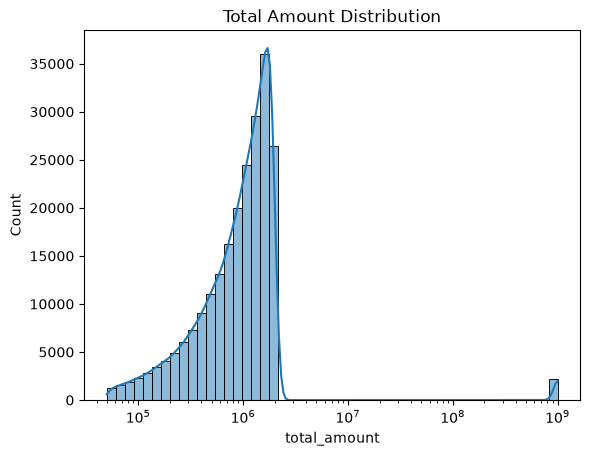

In [103]:
sns.histplot(data=corr_gmv_table, x='total_amount', bins=50, kde=True, log_scale=True)
plt.title('Total Amount Distribution')
plt.show()

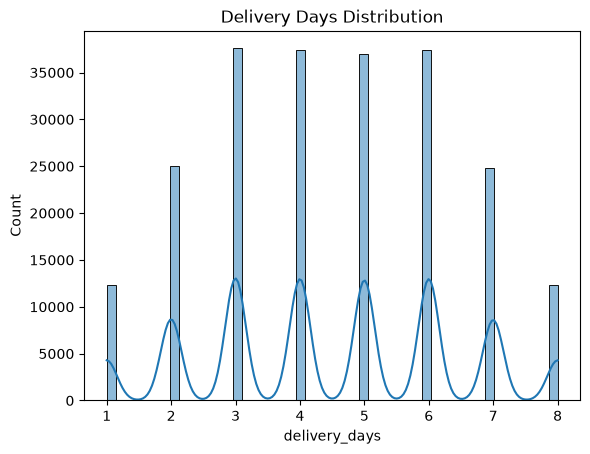

In [104]:
sns.histplot(data=corr_gmv_table, x='delivery_days', bins=50, kde=True)
plt.title('Delivery Days Distribution')
plt.show()

In [105]:
# Buat tabel baru per lokasi

location_table=corr_gmv_table.groupby('location').agg(
    total_order=('total_amount', 'count'),
    total_gmv=('total_amount', 'sum'),
    mean_gmv=('total_amount', 'mean'),
    median_gmv=('total_amount', 'median'),
    mean_durasi=('delivery_days', 'mean'),
    median_durasi=('delivery_days', 'median'))
location_table

,total_order,total_gmv,mean_gmv,median_gmv,mean_durasi,median_durasi
location,,,,,,
Bandung,37341,407010054213,1.089982e+07,1038312.0,4.502156,4.0
Jakarta,37127,417645529464,1.124911e+07,1037908.0,4.490075,4.0
Makassar,37717,443179135344,1.175012e+07,1032338.0,4.497733,4.0
Medan,37236,387888863434,1.041704e+07,1035396.5,4.474621,4.0
Surabaya,37561,402045267048,1.070380e+07,1031482.0,4.510024,5.0
Yogyakarta,36780,407243023717,1.107240e+07,1035419.5,4.498178,4.0


In [106]:
location_table.corr()

,total_order,total_gmv,mean_gmv,median_gmv,mean_durasi,median_durasi
total_order,1.000000,0.429349,0.246676,-0.569023,0.293244,0.395642
total_gmv,0.429349,1.000000,0.981128,-0.225895,0.312864,-0.231917
mean_gmv,0.246676,0.981128,1.000000,-0.120205,0.276327,-0.330562
median_gmv,-0.569023,-0.225895,-0.120205,1.000000,-0.342050,-0.641306
mean_durasi,0.293244,0.312864,0.276327,-0.342050,1.000000,0.589186
median_durasi,0.395642,-0.231917,-0.330562,-0.641306,0.589186,1.000000


In [107]:
corr_gmv_table[corr_gmv_table.select_dtypes('number').columns].corr(method='spearman')

,delivery_days,total_amount
delivery_days,1.000000,0.001479
total_amount,0.001479,1.000000


In [108]:
location_table[location_table.select_dtypes('number').columns].corr(method='spearman')

,total_order,total_gmv,mean_gmv,median_gmv,mean_durasi,median_durasi
total_order,1.000000,0.085714,0.085714,-0.542857,0.314286,0.392792
total_gmv,0.085714,1.000000,1.000000,0.142857,-0.085714,-0.392792
mean_gmv,0.085714,1.000000,1.000000,0.142857,-0.085714,-0.392792
median_gmv,-0.542857,0.142857,0.142857,1.000000,-0.142857,-0.654654
mean_durasi,0.314286,-0.085714,-0.085714,-0.142857,1.000000,0.654654
median_durasi,0.392792,-0.392792,-0.392792,-0.654654,0.654654,1.000000


In [109]:
corr_gmv_table['delivery_days'].corr(corr_gmv_table['total_amount'],method='spearman')

np.float64(0.0014786015504129855)

<Axes: xlabel='delivery_days', ylabel='total_amount'>

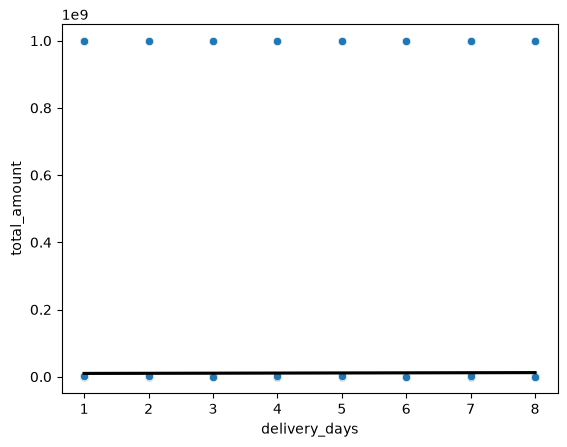

In [110]:
sns.scatterplot(data=corr_gmv_table,x='delivery_days',y='total_amount')
sns.regplot(data=corr_gmv_table,x='delivery_days',y='total_amount',color='black',ci=None,scatter=False)

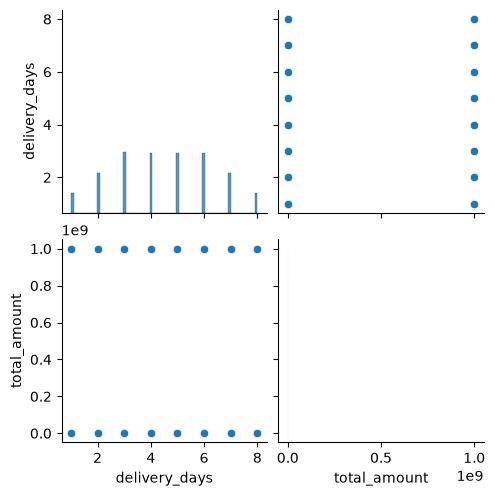

In [111]:
sns.pairplot(corr_gmv_table)

**Kesimpulan No. 4:**<br>
Korelasi antara lokasi dan durasi pengiriman dengan GMV hanya 0,00148. Artinya, tidak ada korelasi antara lokasi dan durasi pengiriman dengan GMV. Tiap kota memiliki pola durasi pengiriman dan nilai transaksi yang mirip.

## **5. Apakah ada anomali data sistem (seperti tanggal transaksi mendahului tanggal registrasi) yang mengindikasikan kebocoran atau bug pada platform?**

Ada 2 anomali data sistem :
1. Nilai promo_amount lebih besar daripada total_amount (promo_amount>total_amount)
2. Tanggal registrasi (join_date), tanggal transaksi (order_date), tanggal pengiriman(dispatch_date), tanggal orderan diterima user (delivery_date) saling mendahului. Kondisi tanggal tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date

In [112]:
# Nilai promo_amount lebih besar daripada total_amount (promo_amount>total_amount)

amount_invalid

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age
146,ORD000147,USR03087,2023-08-22,GoPay,0,-150000,GoTo Logistics,2023-08-22,2023-08-26,2022-10-08,Male,Surabaya,33
438,ORD000439,USR36168,2023-06-18,BCA VA,0,-150000,JNE,2023-06-18,2023-06-22,2022-09-08,Female,Yogyakarta,23
565,ORD000566,USR37484,2023-11-27,GoPay,0,-150000,AnterAja,2023-11-27,2023-11-30,2023-03-04,Unknown,Surabaya,43
612,ORD000613,USR33803,2022-08-08,BCA VA,10000,-150000,SiCepat,2022-08-08,2022-08-09,2022-10-29,Male,Jakarta,62
653,ORD000654,USR09711,2024-08-09,GoPay,0,-150000,GoTo Logistics,2024-08-11,2024-08-17,2023-12-09,Male,Medan,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299537,ORD299538,USR24375,2022-12-21,OVO,0,-150000,AnterAja,2022-12-23,2022-12-25,2022-10-14,Female,Bandung,51
299719,ORD299720,USR31958,2022-08-26,BCA VA,0,-150000,JNE,2022-08-26,2022-09-01,2022-06-07,Female,Surabaya,45
299798,ORD299799,USR47142,2023-11-26,OVO,20000,-150000,SiCepat,2023-11-27,2023-12-02,2023-04-20,Male,Bandung,26
299865,ORD299866,USR11226,2023-09-16,GoPay,10000,-150000,SiCepat,2023-09-16,2023-09-21,2023-06-11,Male,Jakarta,19


In [132]:
users_transactions_all

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46


In [134]:
# Cek persentase anomali data bagian promo amount>total_amount

persentase_anomali_promo=len(amount_invalid)/(len(users_transactions_all)+len(amount_invalid))*100
print(f'Persentase anomali data yang nilai promo_amount lebih besar daripada total_amount (promo_amount>total_amount) adalah {persentase_anomali_promo}%')

Persentase anomali data yang nilai promo_amount lebih besar daripada total_amount (promo_amount>total_amount) adalah 1.0106666666666666%


Ada 3032 anomali data yang nilai promo_amount lebih besar daripada total_amount.


In [113]:
# Tanggal registrasi (join_date), tanggal transaksi (order_date), tanggal pengiriman(dispatch_date), tanggal orderan diterima user (delivery_date) saling mendahului
# Kondisi tanggal tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date

data_date_invalid

,order_id,user_id_x,order_date_x,payment_method_x,promo_amount_x,total_amount_x,courier_name_x,dispatch_date_x,delivery_date_x,join_date_x,...,payment_method_y,promo_amount_y,total_amount_y,courier_name_y,dispatch_date_y,delivery_date_y,join_date_y,gender_y,location_y,age_y
10,ORD000011,USR24868,2023-01-28,GoPay,10000,874696,GoTo Logistics,2023-01-30,2023-01-26,2022-07-29,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
12,ORD000013,USR42846,2024-02-19,GoPay,20000,67960,GoTo Logistics,2024-02-21,2024-02-18,2023-05-25,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
16,ORD000017,USR06240,2022-11-09,Mandiri VA,10000,1387886,SiCepat,2022-11-10,2022-11-07,2022-06-24,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
25,ORD000026,USR08593,2022-03-11,BCA VA,0,809890,AnterAja,2022-03-12,2022-03-15,2022-06-07,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
40,ORD000041,USR06584,2023-01-01,Mandiri VA,0,125754,SiCepat,2023-01-02,2023-01-08,2023-03-23,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296903,ORD299936,USR15274,2023-08-23,Mandiri VA,20000,807897,GoTo Logistics,2023-08-24,2023-08-29,2023-10-04,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
296948,ORD299981,USR48209,2023-03-07,GoPay,10000,433546,GoTo Logistics,2023-03-08,2023-03-06,2022-04-13,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
296952,ORD299985,USR08396,2022-05-29,Mandiri VA,0,1429297,JNE,2022-05-29,2022-05-25,2022-02-20,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
296954,ORD299987,USR13831,2024-03-10,Mandiri VA,0,882602,JNE,2024-03-12,2024-03-09,2023-06-22,...,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN


Ada 23310 anomali data yang data tanggalnya tidak memenuhi kondisi join_date<=order_date<=dispatch_date<=delivery_date.

In [140]:
# Cek persentase anomali data yang kondisi tanggal tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date

anomali_date=transactions_all.merge(users, on='user_id', how='left')
anomali_date_all=anomali_date[~(anomali_date['join_date']<=anomali_date['order_date'])&
    (anomali_date['order_date']<=anomali_date['dispatch_date']) &
    (anomali_date['dispatch_date']<=anomali_date['delivery_date'])]

persentase_anomali_date=len(anomali_date_all)/len(anomali_date)*100

print(f'Persentase anomali data yang kondisi tanggal tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date adalah {persentase_anomali_date}%')

Persentase anomali data yang kondisi tanggal tidak memenuhi join_date<=order_date<=dispatch_date<=delivery_date adalah 4.846666666666667%


**Kesimpulan No. 5:**<br>
Terdapat anomali data sistem. Anomali data pada bagian promo amount dengan total amount sebesar 1,01% dari total order secara keseluruhan order. Anomali data pada tanggal orderan yang tidak valid sebesar 4,85% dari total order secara keseluruhan.

## **6. Berapa persentase budget promo yang sebenarnya terbuang untuk transaksi-transaksi yang secara bisnis tidak valid (outliers & fraud)?**

In [114]:
budget_promo_table=transactions_all.merge(users, on='user_id', how='left')
display(budget_promo_table)

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947,GoTo Logistics,2023-09-26,2023-09-30,2023-07-08,Female,Jakarta,20,2023,2023-07-01
1,ORD000002,USR26336,2022-08-10,OVO,10000,1054104,SiCepat,2022-08-12,2022-08-16,2022-01-03,Male,Medan,23,2022,2022-01-01
2,ORD000003,USR25466,2024-05-21,COD,0,1067647,JNE,2024-05-23,2024-05-26,2023-07-01,Male,Jakarta,46,2023,2023-07-01
3,ORD000004,USR42303,2024-06-18,OVO,10000,175629,GoTo Logistics,2024-06-18,2024-06-23,2023-06-23,Female,Yogyakarta,35,2023,2023-06-01
4,ORD000005,USR29370,2024-03-11,OVO,0,1438378,SiCepat,2024-03-13,2024-03-14,2023-07-31,Female,Yogyakarta,39,2023,2023-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,ORD299996,USR28800,2024-06-14,GoPay,10000,1664986,GoTo Logistics,2024-06-14,2024-06-20,2023-08-28,Male,Bandung,50,2023,2023-08-01
299996,ORD299997,USR34293,2023-02-09,BCA VA,0,1879130,JNE,2023-02-10,2023-02-12,2022-07-17,Male,Medan,49,2022,2022-07-01
299997,ORD299998,USR18612,2023-03-14,GoPay,10000,973388,GoTo Logistics,2023-03-14,2023-03-19,2022-05-20,Female,Makassar,64,2022,2022-05-01
299998,ORD299999,USR07211,2023-04-09,COD,10000,1545572,GoTo Logistics,2023-04-11,2023-04-15,2022-12-09,Male,Bandung,46,2022,2022-12-01


In [115]:
# Data invalid yang promo amount > total amount disimpan dalam tabel baru
promo_amount_invalid=budget_promo_table[budget_promo_table['promo_amount']>budget_promo_table['total_amount']]

promo_amount_invalid

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month
146,ORD000147,USR03087,2023-08-22,GoPay,0,-150000,GoTo Logistics,2023-08-22,2023-08-26,2022-10-08,Male,Surabaya,33,2022,2022-10-01
438,ORD000439,USR36168,2023-06-18,BCA VA,0,-150000,JNE,2023-06-18,2023-06-22,2022-09-08,Female,Yogyakarta,23,2022,2022-09-01
565,ORD000566,USR37484,2023-11-27,GoPay,0,-150000,AnterAja,2023-11-27,2023-11-30,2023-03-04,Unknown,Surabaya,43,2023,2023-03-01
612,ORD000613,USR33803,2022-08-08,BCA VA,10000,-150000,SiCepat,2022-08-08,2022-08-09,2022-10-29,Male,Jakarta,62,2022,2022-10-01
653,ORD000654,USR09711,2024-08-09,GoPay,0,-150000,GoTo Logistics,2024-08-11,2024-08-17,2023-12-09,Male,Medan,23,2023,2023-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299537,ORD299538,USR24375,2022-12-21,OVO,0,-150000,AnterAja,2022-12-23,2022-12-25,2022-10-14,Female,Bandung,51,2022,2022-10-01
299719,ORD299720,USR31958,2022-08-26,BCA VA,0,-150000,JNE,2022-08-26,2022-09-01,2022-06-07,Female,Surabaya,45,2022,2022-06-01
299798,ORD299799,USR47142,2023-11-26,OVO,20000,-150000,SiCepat,2023-11-27,2023-12-02,2023-04-20,Male,Bandung,26,2023,2023-04-01
299865,ORD299866,USR11226,2023-09-16,GoPay,10000,-150000,SiCepat,2023-09-16,2023-09-21,2023-06-11,Male,Jakarta,19,2023,2023-06-01


In [116]:
# Data invalid yang ada tanggal invalid

date_promo_invalid=budget_promo_table[~(budget_promo_table['join_date']<=budget_promo_table['order_date'])&
    (budget_promo_table['order_date']<=budget_promo_table['dispatch_date']) &
    (budget_promo_table['dispatch_date']<=budget_promo_table['delivery_date'])]

date_promo_invalid

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month
25,ORD000026,USR08593,2022-03-11,BCA VA,0,809890,AnterAja,2022-03-12,2022-03-15,2022-06-07,Unknown,Yogyakarta,32,2022,2022-06-01
40,ORD000041,USR06584,2023-01-01,Mandiri VA,0,125754,SiCepat,2023-01-02,2023-01-08,2023-03-23,Unknown,Bandung,32,2023,2023-03-01
45,ORD000046,USR10466,2023-07-17,OVO,0,1490660,GoTo Logistics,2023-07-19,2023-07-22,2023-09-10,Female,Jakarta,57,2023,2023-09-01
48,ORD000049,USR37607,2023-05-18,COD,20000,451529,SiCepat,2023-05-19,2023-05-20,2023-06-01,Male,Makassar,55,2023,2023-06-01
107,ORD000108,USR33802,2022-09-17,OVO,10000,1799415,JNE,2022-09-17,2022-09-18,2022-11-05,Male,Bandung,53,2022,2022-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299895,ORD299896,USR15385,2022-05-10,COD,50000,1074413,GoTo Logistics,2022-05-10,2022-05-14,2022-08-02,Female,Jakarta,33,2022,2022-08-01
299914,ORD299915,USR37673,2022-07-30,BCA VA,10000,1742783,GoTo Logistics,2022-08-01,2022-08-03,2022-08-21,Male,Bandung,63,2022,2022-08-01
299916,ORD299917,USR15798,2022-05-06,GoPay,0,620263,JNE,2022-05-06,2022-05-09,2022-05-28,Female,Jakarta,31,2022,2022-05-01
299935,ORD299936,USR15274,2023-08-23,Mandiri VA,20000,807897,GoTo Logistics,2023-08-24,2023-08-29,2023-10-04,Female,Bandung,56,2023,2023-10-01


In [117]:
# Menggabungkan tabel promo_amount_invalid & date_promo_invalid
date_promo_invalid=pd.concat([promo_amount_invalid,date_promo_invalid],ignore_index=True)
date_promo_invalid.drop_duplicates(inplace=True)
date_promo_invalid

,order_id,user_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,join_date,gender,location,age,join_year,join_month
0,ORD000147,USR03087,2023-08-22,GoPay,0,-150000,GoTo Logistics,2023-08-22,2023-08-26,2022-10-08,Male,Surabaya,33,2022,2022-10-01
1,ORD000439,USR36168,2023-06-18,BCA VA,0,-150000,JNE,2023-06-18,2023-06-22,2022-09-08,Female,Yogyakarta,23,2022,2022-09-01
2,ORD000566,USR37484,2023-11-27,GoPay,0,-150000,AnterAja,2023-11-27,2023-11-30,2023-03-04,Unknown,Surabaya,43,2023,2023-03-01
3,ORD000613,USR33803,2022-08-08,BCA VA,10000,-150000,SiCepat,2022-08-08,2022-08-09,2022-10-29,Male,Jakarta,62,2022,2022-10-01
4,ORD000654,USR09711,2024-08-09,GoPay,0,-150000,GoTo Logistics,2024-08-11,2024-08-17,2023-12-09,Male,Medan,23,2023,2023-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17567,ORD299896,USR15385,2022-05-10,COD,50000,1074413,GoTo Logistics,2022-05-10,2022-05-14,2022-08-02,Female,Jakarta,33,2022,2022-08-01
17568,ORD299915,USR37673,2022-07-30,BCA VA,10000,1742783,GoTo Logistics,2022-08-01,2022-08-03,2022-08-21,Male,Bandung,63,2022,2022-08-01
17569,ORD299917,USR15798,2022-05-06,GoPay,0,620263,JNE,2022-05-06,2022-05-09,2022-05-28,Female,Jakarta,31,2022,2022-05-01
17570,ORD299936,USR15274,2023-08-23,Mandiri VA,20000,807897,GoTo Logistics,2023-08-24,2023-08-29,2023-10-04,Female,Bandung,56,2023,2023-10-01


In [118]:
# Budget promo keseluruhan
print(f'Jumlah orderan: {budget_promo_table['order_id'].count()}')
print(f'Jumlah budget promo: Rp {budget_promo_table['promo_amount'].sum():,.0f}')

Jumlah orderan: 300000
Jumlah budget promo: Rp 2,242,080,000


In [119]:
# Budget promo yang terbuang sia-sia
print(f'Jumlah orderan yang budget promonya terbuang: {date_promo_invalid['order_id'].count()}')
print(f'Jumlah budget promo yang terbuang: Rp {date_promo_invalid['promo_amount'].sum():,.0f}')

Jumlah orderan yang budget promonya terbuang: 17430
Jumlah budget promo yang terbuang: Rp 132,150,000


In [120]:
# Persentase budget promo yang terbuang
# Budget promo yang terbuang sia-sia
print(f'Persentase orderan yang budget promonya terbuang: {date_promo_invalid['order_id'].count()/budget_promo_table['order_id'].count()*100}%')
print(f'Jumlah budget promo yang terbuang: {date_promo_invalid['promo_amount'].sum()/budget_promo_table['promo_amount'].sum()*100}%')

Persentase orderan yang budget promonya terbuang: 5.81%
Jumlah budget promo yang terbuang: 5.894080496681653%


In [121]:
# Budget promo yang terbuang berdasarkan metode pembayaran

promo_payment_tabel=date_promo_invalid.groupby('payment_method').agg(promo_terbuang=('promo_amount','sum'))

promo_payment_tabel['total_promo']=budget_promo_table.groupby('payment_method').agg(total_promo=('promo_amount','sum'))

promo_payment_tabel['persen_promo_terbuang']=promo_payment_tabel['promo_terbuang']/promo_payment_tabel['total_promo']*100

promo_payment_tabel

,promo_terbuang,total_promo,persen_promo_terbuang
payment_method,,,
BCA VA,30060000,501940000,5.988764
COD,14620000,249470000,5.860424
GoPay,43200000,745440000,5.795235
Mandiri VA,14700000,249910000,5.882118
OVO,29570000,495320000,5.969878


In [122]:
# Tambah kolom lift untuk membandingkan dengan mean keseluruhan data invalid

mean_promo_terbuang=promo_payment_tabel['promo_terbuang'].sum()/promo_payment_tabel['total_promo'].sum()*100

mean_promo_terbuang

np.float64(5.894080496681653)

In [123]:
promo_payment_tabel['lift_promo_terbuang']=promo_payment_tabel['persen_promo_terbuang']/mean_promo_terbuang

promo_payment_tabel

,promo_terbuang,total_promo,persen_promo_terbuang,lift_promo_terbuang
payment_method,,,,
BCA VA,30060000,501940000,5.988764,1.016064
COD,14620000,249470000,5.860424,0.994290
GoPay,43200000,745440000,5.795235,0.983230
Mandiri VA,14700000,249910000,5.882118,0.997970
OVO,29570000,495320000,5.969878,1.012860


**Kesimpulan No. 6:**<br>
Persentase orderan yang budget promonya terbuang sebesar 5.81% dan persentase budget promo yang terbuang sebesar 5.89%. Persentase budget promo terbuang tiap metode pembayaran berada di kisaran 5.89% juga. Artinya, budget promo terbuang merata di semua metode pembayaran, tidak ada budget promo berdasarkan metode pembayaran yang menonjol.

# **Kesimpulan**

1. Promo hunter tidak dapat dikenali dari gender, lokasi, dan metode pembayaran. Karakteristik promo hunter mungkin lebih terlihat dari perilaku user seperti frekuensi order, proporsi order promo, dan jeda antarorder.

2. Keterlambatan pengiriman berdampak kecil pada peluang repeat order. Perbedaan peluang repeat order berdasarkann terlambat atau tidaknya pengiriman hanya sebesar 2% tetapi skalanya besar.

3. Anomali tiap metode pembayaran namun relatif sama untuk anomali nilai total transaksi (nilai promo > nilai transaksi) dan anomali tanggal transaksi yang tidak sesuai. Anomali ini bersifat sistematik. Sumber masalah adanya anomali ini kemungkinan ada di aplikasi.

4. Tidak ada korelasi antara lokasi dan durasi pengiriman dengan GMV. Artinya, lokasi dan durasi pengiriman tidak menentukan nilai transaksi sehingga GMV tidak perlu dibedakan tiap lokasi.

5. Terdapat anomali data sistem, yaitu bagian nilai promo yang lebih besar dari niali transaksi dan data tanggal transaksi. Walaupun persentase anomali datanya cenderung kecil, namun banyak budget promo yang terbuang. Anomali data ini mengindikasikan lemahnya validasi di sistem.



# **Rekomendasi**

1. Perbaiki kebocoran atau bug pada platform ada bagian nilai promo yang lebih besar dari nilai total transaksi dan tanggal order yang tidak valid. Perbaikan ini penting dilakukan agar dapat mencegah budget promo yang terbuang, optimalisasi budget promo, dan mempermudah data analyst untuk menganalisis data lebih lanjut.
2. Targetkan promo berdasarkan perilaku user
3. Peningkatan SLA logistik dengan evaluasi kurir/rekanan jasa kirim dengan SLA miss tertinggi
4. Pemberian kompensasi apabila terdapat SLA miss untuk meningkatkan repeat order user seperti memberi voucher yang berlaku untuk order berikutnya.
5. Mengumpulkan ulasan atau tiket komplain untuk menemukan faktor-faktor repeat order user.

# **LOAD**

In [124]:
import pandas_gbq
from google.oauth2 import service_account
from google.cloud import bigquery

In [125]:
dataset_id='capstone_tokopedia'
scopes=["https://www.googleapis.com/auth/bigquery"]
credentials=service_account.Credentials.from_service_account_file(filename='tangential-sled-508802-g2-277fbd996b9d.json',
                                                                  scopes=scopes)

In [ ]:
table_name = 'users_transactions_all_new'

pandas_gbq.to_gbq(dataframe=users_transactions_all_new, 
                  destination_table = f'{dataset_id}.{table_name}',
                  project_id = 'tangential-sled-508802-g2',
                  if_exists = 'replace',
                  credentials = credentials)

In [126]:
table_name = 'SLA_table'

pandas_gbq.to_gbq(dataframe=SLA_table, 
                  destination_table = f'{dataset_id}.{table_name}',
                  project_id = 'tangential-sled-508802-g2',
                  if_exists = 'replace',
                  credentials = credentials)

In [127]:
table_name = 'promo_hunter_table'

pandas_gbq.to_gbq(dataframe=promo_hunter_table, 
                  destination_table = f'{dataset_id}.{table_name}',
                  project_id = 'tangential-sled-508802-g2',
                  if_exists = 'replace',
                  credentials = credentials)